In [1]:
import pickle
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import eelbrain
from eelbrain import combine


In [2]:
data_acoustic = eelbrain.load.unpickle(f"pickles/encoding_2026-04-20/Sub3_['envelope', 'onsets']_acoustic_data.pkl")
data_acoustic['trf_cv']

<BoostingResult eeg ~ envelope + onsets, -0.05 - 0.55, error=l1, basis=0.05, partitions=4, test=True>

In [3]:
def permutation_test(a, b, n_permutations=10000, two_tailed=True, seed=42):
    """Sign-flip permutation test for paired data."""
    rng = np.random.default_rng(seed)
    diff = b - a
    observed = diff.mean()
    
    count = 0
    for _ in range(n_permutations):
        signs = rng.choice([-1, 1], size=len(diff))
        perm_mean = (signs * diff).mean()
        if two_tailed:
            count += abs(perm_mean) >= abs(observed)
        else:
            count += perm_mean >= observed
    
    p_val = count / n_permutations
    return observed, p_val


In [4]:
def plot(n_subjects, pickle_folder, pickle_acoustic_filename, pickle_surprisal_filename):
    # ── 1. Load all subjects ──────────────────────────────────────────────────────
    n_subjects = n_subjects
    r_acoustic_all = []  # will be shape (n_subjects, n_channels)
    r_full_all     = []

    for sub in range(1, n_subjects + 1):
        try:
            data_acoustic = eelbrain.load.unpickle(f"pickles/{pickle_folder}/Sub{sub}_['envelope', 'onsets']_{pickle_acoustic_filename}.pkl")
            data_full     = eelbrain.load.unpickle(f"pickles/{pickle_folder}/Sub{sub}_['envelope', 'onsets', 'pitch_surprisal', 'pitch_entropy', 'onset_surprisal', 'onset_entropy']_{pickle_surprisal_filename}.pkl")

            r_acoustic_all.append(data_acoustic['trf_cv'].r.get_data('sensor'))
            r_full_all.append(data_full['trf_cv'].r.get_data('sensor'))
            print(f"  Sub{sub:02d} loaded")

        except FileNotFoundError:
            print(f"  Sub{sub:02d} missing — skipping")

    r_acoustic_all = np.array(r_acoustic_all)  # (n_subjects, n_channels)
    r_full_all     = np.array(r_full_all)
    n_subjects     = len(r_acoustic_all)       # update in case any were skipped

    print(f"\nLoaded {n_subjects} subjects, {r_acoustic_all.shape[1]} channels each")

    # ── 2. Per-subject mean r (averaged across channels) ─────────────────────────
    r_acoustic_per_sub = r_acoustic_all.mean(axis=1)  # (n_subjects,)
    r_full_per_sub     = r_full_all.mean(axis=1)
    r_diff_per_sub     = r_full_per_sub - r_acoustic_per_sub

    # ── 3. Group-level statistics — two-tailed sign-flip permutation test ─────────
    mean_diff, p_val = permutation_test(r_acoustic_per_sub, r_full_per_sub,
                                        n_permutations=10000, two_tailed=True)
    sem_diff = r_diff_per_sub.std() / np.sqrt(n_subjects)

    # Per-channel permutation test across subjects + FDR correction
    n_channels    = r_acoustic_all.shape[1]
    p_per_channel = np.array([
        permutation_test(r_acoustic_all[:, ch], r_full_all[:, ch],
                        n_permutations=10000, two_tailed=True)[1]
        for ch in range(n_channels)
    ])
    _, p_fdr = fdrcorrection(p_per_channel)

    sig_label = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    print(f"\nGroup-level permutation test (mean r across channels):")
    print(f"  p = {p_val:.4f}  {sig_label}")
    print(f"  Mean Δr = {mean_diff:.4f} ± {sem_diff:.4f} SEM")
    print(f"  Channels significant after FDR (p<0.05): {(p_fdr < 0.05).sum()} / {n_channels}")


    # ── 4. Figure 1 – Violin: group-level acoustic vs full ───────────────────────
    fig, ax = plt.subplots(figsize=(7, 6))

    data   = [r_acoustic_per_sub, r_full_per_sub]
    labels = ['Acoustic\n(envelope)', 'Full\n(+ onsets + surprisal + entropy)']
    colors = ['steelblue', 'darkorange']

    parts = ax.violinplot(data, positions=[1, 2], showmedians=False, showextrema=False)
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.6)

    # Individual subject points connected by lines
    for i in range(n_subjects):
        ax.plot([1, 2], [r_acoustic_per_sub[i], r_full_per_sub[i]],
                color='gray', alpha=0.4, linewidth=0.8)
        # ax.text(1-0.08,r_acoustic_per_sub[i], f'{r_acoustic_per_sub[i]:.4f}', 
        #         fontsize=8, va='center', ha='right', alpha=0.7)
        # ax.text(2 + 0.08, r_full_per_sub[i], f'{r_full_per_sub[i]:.4f}', 
        #         fontsize=8, va='center', ha='left', alpha=0.7)
        
    for i, (d, color) in enumerate(zip(data, colors), start=1):
        jitter = np.random.uniform(-0.04, 0.04, size=len(d))
        ax.scatter(i + jitter, d, color=color, s=40, alpha=0.8,
                edgecolors='white', linewidths=0.5, zorder=4)

    # Mean ± SEM
    for i, d in enumerate(data, start=1):
        mean_val = d.mean()
        
        ax.errorbar(i, mean_val, yerr=d.std() / np.sqrt(len(d)),
                    fmt='o', color='black', markersize=7, capsize=5, linewidth=2, zorder=5)
        ax.text(i + 0.08, mean_val, f'Mean: {mean_val:.4f}', 
                color='black', fontsize=10, fontweight='bold', va='center', ha='left', zorder=6)

    # Significance bracket
    y_bracket = max(r_acoustic_per_sub.max(), r_full_per_sub.max()) + 0.005
    ax.plot([1, 1, 2, 2], [y_bracket - 0.003, y_bracket, y_bracket, y_bracket - 0.003],
            color='black', linewidth=1.2)
    ax.text(1.5, y_bracket + 0.003, f'p = {p_val:.4f}  {sig_label}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel('Mean CV Correlation (r)', fontsize=12)
    ax.set_title(f'Group-Level Encoding Correlation\n(N = {n_subjects} subjects)', fontsize=13)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlim(0.4, 2.6)
    plt.tight_layout()
    # plt.savefig('group_violin.png', dpi=150)
    plt.show()

    # ── 5. Figure 2 – Per-subject Δr bar chart ───────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 4))
    sub_labels = [f'Sub{i+1:02d}' for i in range(n_subjects)]
    colors_bar = ['seagreen' if d > 0 else 'crimson' for d in r_diff_per_sub]

    ax.bar(range(n_subjects), r_diff_per_sub, color=colors_bar, alpha=0.8, edgecolor='white')
    ax.axhline(0,         color='gray',  linewidth=0.8)
    ax.axhline(mean_diff, color='black', linewidth=1.5, linestyle='--',
            label=f'Group mean Δr = {mean_diff:.4f}')
    ax.set_xticks(range(n_subjects))
    ax.set_xticklabels(sub_labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Δr (full − acoustic)')
    ax.set_title('Per-Subject Improvement from Adding Surprisal + Entropy\n(green = improvement, red = worse)')
    ax.legend()
    plt.tight_layout()
    # plt.savefig('group_delta_r_per_subject.png', dpi=150)
    plt.show()

    # ── 6. Figure 3 – Per-channel group Δr with FDR-corrected significance ───────
    r_diff_per_channel = (r_full_all - r_acoustic_all).mean(axis=0)  # (n_channels,)
    channel_names      = data_full['trf_cv'].r.sensor.names

    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

    # Top: mean Δr per channel
    colors_ch = ['seagreen' if d > 0 else 'crimson' for d in r_diff_per_channel]
    axes[0].bar(range(n_channels), r_diff_per_channel, color=colors_ch, alpha=0.8, edgecolor='white')
    axes[0].axhline(0, color='gray', linewidth=0.8)
    axes[0].axhline(r_diff_per_channel.mean(), color='black', linestyle='--', linewidth=1.2,
                    label=f'Mean = {r_diff_per_channel.mean():.4f}')
    axes[0].set_ylabel('Mean Δr across subjects')
    axes[0].set_title('Per-Channel Group Δr (full − acoustic)')
    axes[0].legend()

    # Bottom: -log10(p_fdr) per channel with significance threshold line
    neg_log_p_fdr = -np.log10(np.maximum(p_fdr, 1e-10))
    axes[1].bar(range(n_channels), neg_log_p_fdr, color='mediumpurple', alpha=0.8, edgecolor='white')
    axes[1].axhline(-np.log10(0.05), color='red',    linestyle='--', linewidth=1.2, label='FDR p = 0.05')
    axes[1].axhline(-np.log10(0.01), color='orange', linestyle='--', linewidth=1.2, label='FDR p = 0.01')
    axes[1].set_ylabel('−log₁₀(p_FDR)')
    axes[1].set_title('Per-Channel Significance of Improvement (FDR-corrected permutation test)')
    axes[1].set_xticks(range(n_channels))
    axes[1].set_xticklabels(channel_names, rotation=90, fontsize=7)
    axes[1].legend()

    plt.tight_layout()
    # plt.savefig('group_per_channel.png', dpi=150)
    plt.show()

In [5]:
data_acoustic = eelbrain.load.unpickle(f"pickles/encoding_2026-04-20/Sub3_['envelope', 'onsets']_acoustic_data.pkl")
data_acoustic['trf_cv']

<BoostingResult eeg ~ envelope + onsets, -0.05 - 0.55, error=l1, basis=0.05, partitions=4, test=True>

  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 loaded
  Sub05 loaded
  Sub06 loaded
  Sub07 loaded
  Sub08 loaded
  Sub09 loaded
  Sub10 loaded
  Sub11 loaded
  Sub12 loaded
  Sub13 loaded
  Sub14 loaded
  Sub15 loaded
  Sub16 loaded
  Sub17 loaded
  Sub18 loaded
  Sub19 loaded
  Sub20 loaded

Loaded 20 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 0.1868  ns
  Mean Δr = 0.0002 ± 0.0001 SEM
  Channels significant after FDR (p<0.05): 0 / 64


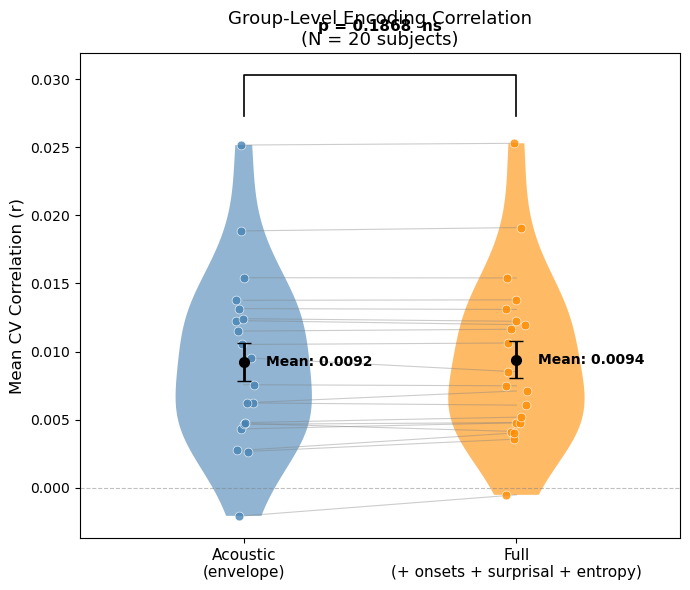

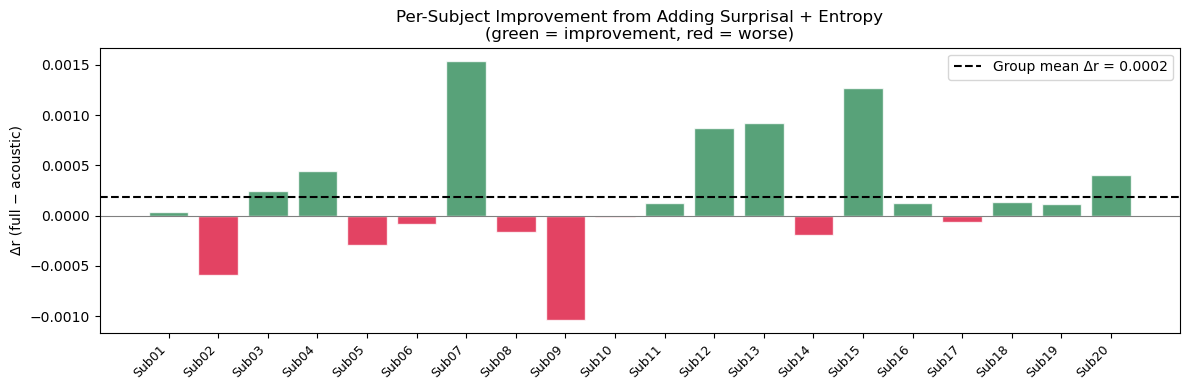

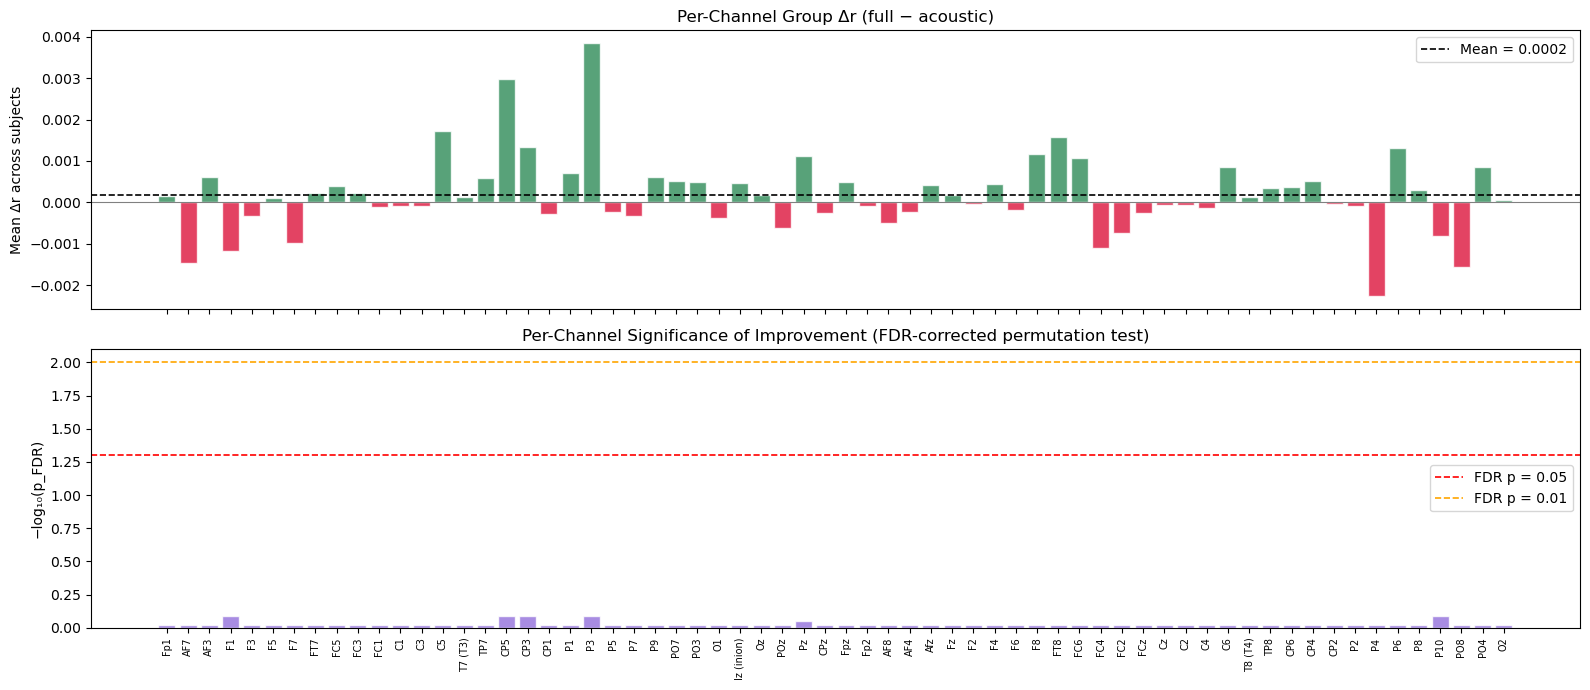

In [6]:
n_subjects = 20
pickle_folder = 'encoding_2026-04-20'
pickle_acoustic_filename = 'acoustic_data'
pickle_surprisal_filename = 'acoustic_and_surprisal_data'

plot(n_subjects, pickle_folder, pickle_acoustic_filename, pickle_surprisal_filename)

In [7]:
data_acoustic = eelbrain.load.unpickle(f"pickles/encoding_2026-04-22/Sub3_['envelope', 'onsets']_acoustic_data.pkl")
data_acoustic['trf_cv']

<BoostingResult eeg ~ envelope + onsets, -0.05 - 0.55, error=l1, basis=0.02, partitions=10, test=True>

  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 loaded
  Sub05 loaded
  Sub06 loaded
  Sub07 loaded
  Sub08 loaded
  Sub09 loaded
  Sub10 loaded
  Sub11 loaded
  Sub12 loaded
  Sub13 loaded
  Sub14 loaded
  Sub15 loaded
  Sub16 loaded
  Sub17 loaded
  Sub18 loaded
  Sub19 loaded
  Sub20 loaded

Loaded 20 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 0.7411  ns
  Mean Δr = -0.0000 ± 0.0001 SEM
  Channels significant after FDR (p<0.05): 0 / 64


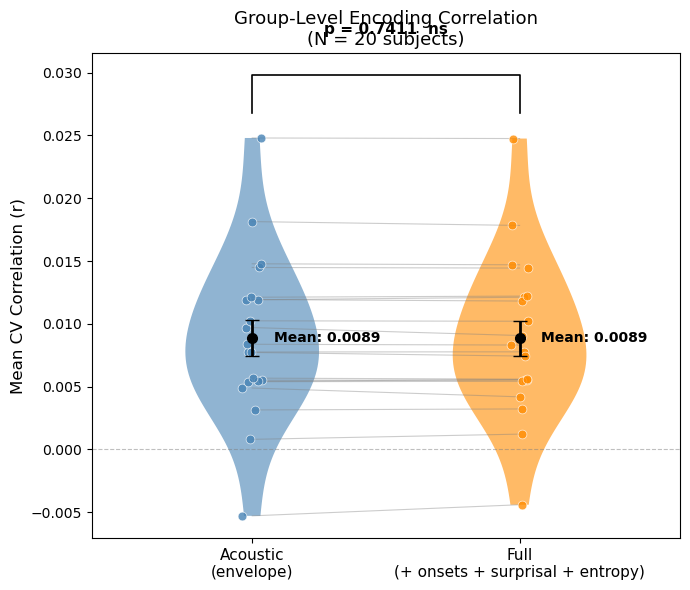

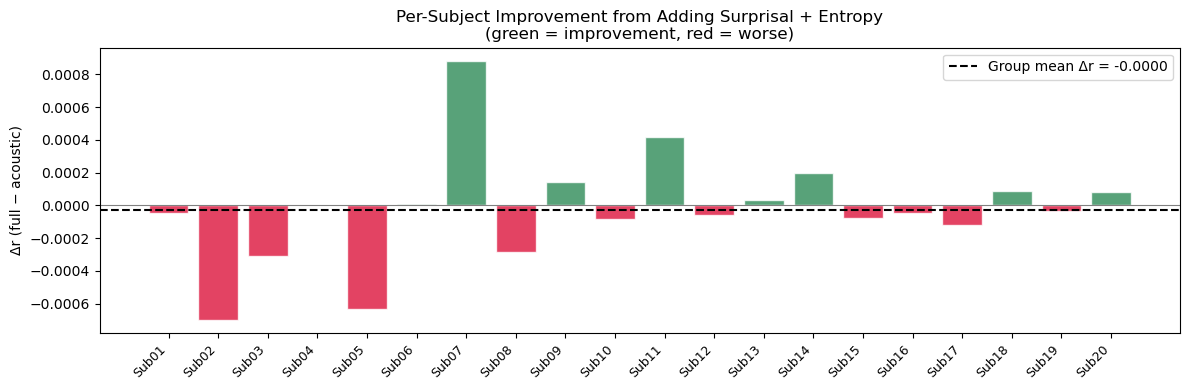

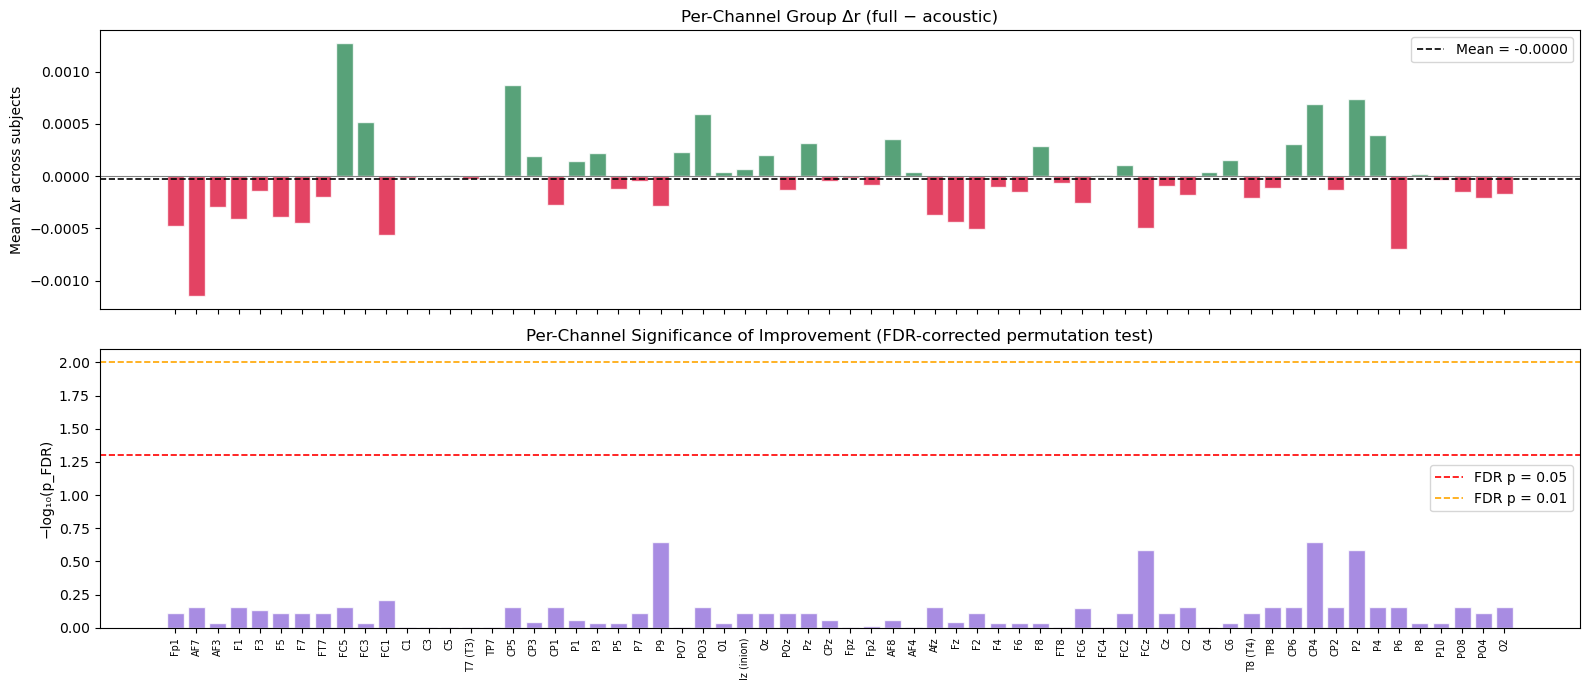

In [8]:
n_subjects = 20
pickle_folder = 'encoding_2026-04-22'
pickle_acoustic_filename = 'acoustic_data'
pickle_surprisal_filename = 'acoustic_and_surprisal_data'

plot(n_subjects, pickle_folder, pickle_acoustic_filename, pickle_surprisal_filename)

  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 loaded
  Sub05 loaded
  Sub06 loaded
  Sub07 loaded
  Sub08 loaded
  Sub09 loaded
  Sub10 loaded
  Sub11 loaded
  Sub12 loaded
  Sub13 loaded
  Sub14 loaded
  Sub15 loaded
  Sub16 loaded
  Sub17 loaded
  Sub18 loaded
  Sub19 loaded
  Sub20 loaded

Loaded 20 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 0.0000  ***
  Mean Δr = 0.0198 ± 0.0036 SEM
  Channels significant after FDR (p<0.05): 64 / 64


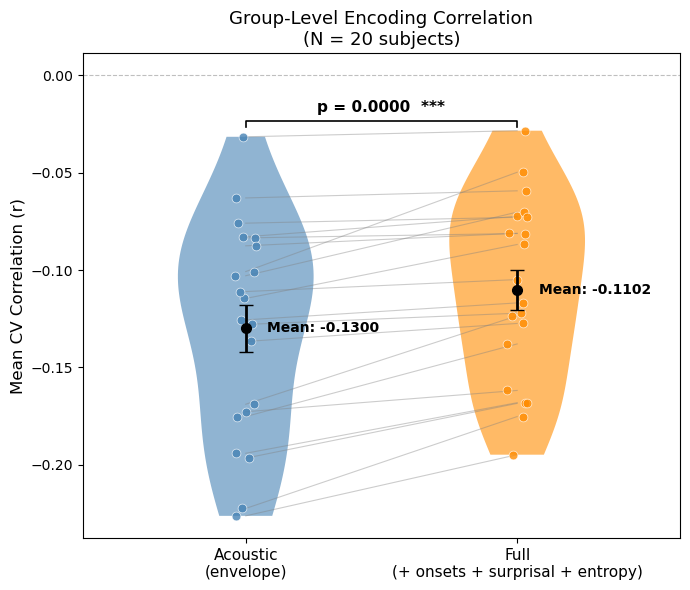

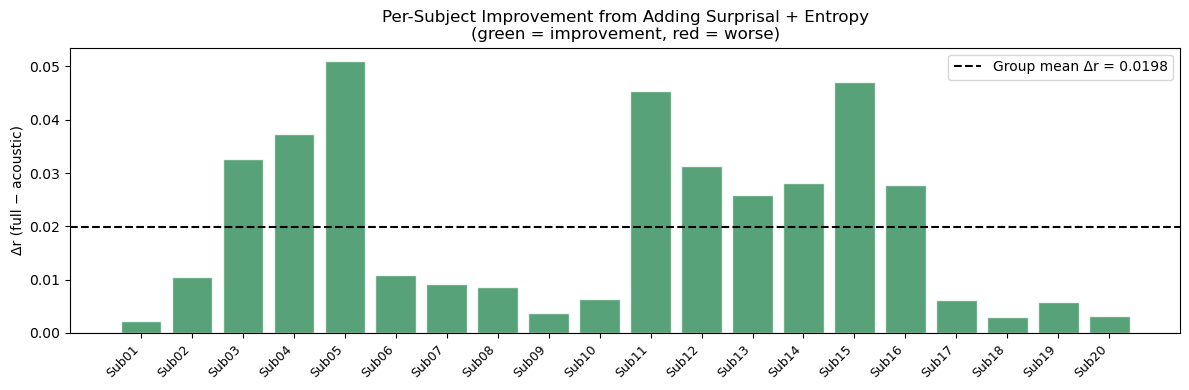

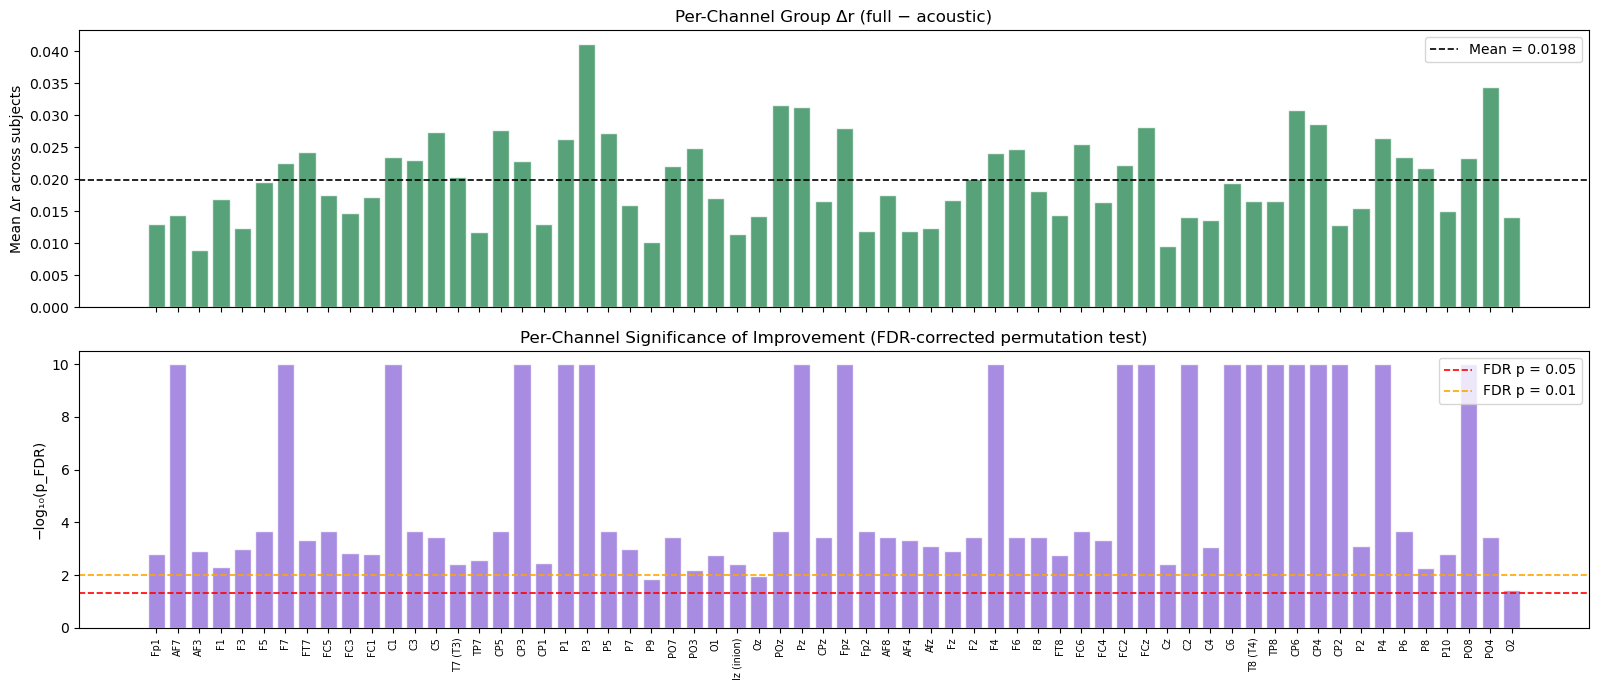

In [9]:
n_subjects = 20
pickle_folder = 'encoding_2026-04-23'
pickle_acoustic_filename = 'mne_ridge_acoustic_data'
pickle_surprisal_filename = 'mne_ridge_acoustic_and_surprisal_data'

plot(n_subjects, pickle_folder, pickle_acoustic_filename, pickle_surprisal_filename)

  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 loaded
  Sub05 loaded
  Sub06 loaded
  Sub07 loaded
  Sub08 loaded
  Sub09 loaded
  Sub10 loaded
  Sub11 loaded
  Sub12 loaded
  Sub13 loaded
  Sub14 loaded
  Sub15 loaded
  Sub16 loaded
  Sub17 loaded
  Sub18 loaded
  Sub19 loaded
  Sub20 loaded

Loaded 20 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 0.0000  ***
  Mean Δr = 0.0166 ± 0.0037 SEM
  Channels significant after FDR (p<0.05): 57 / 64


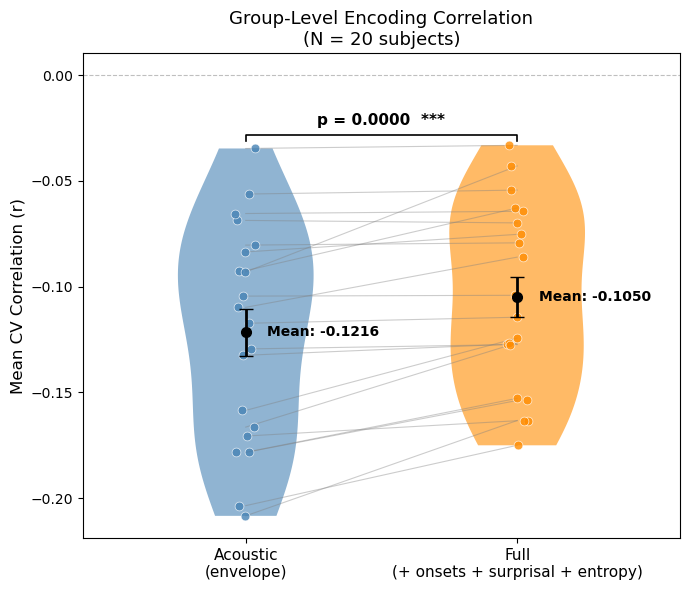

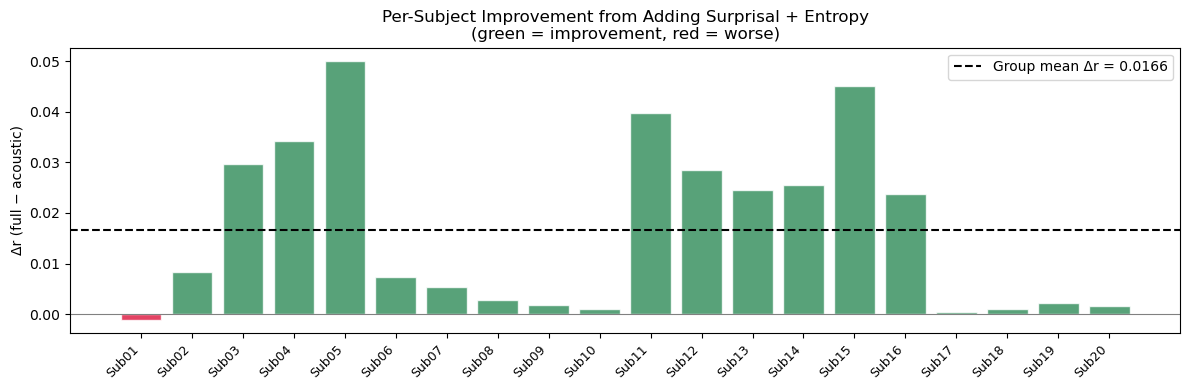

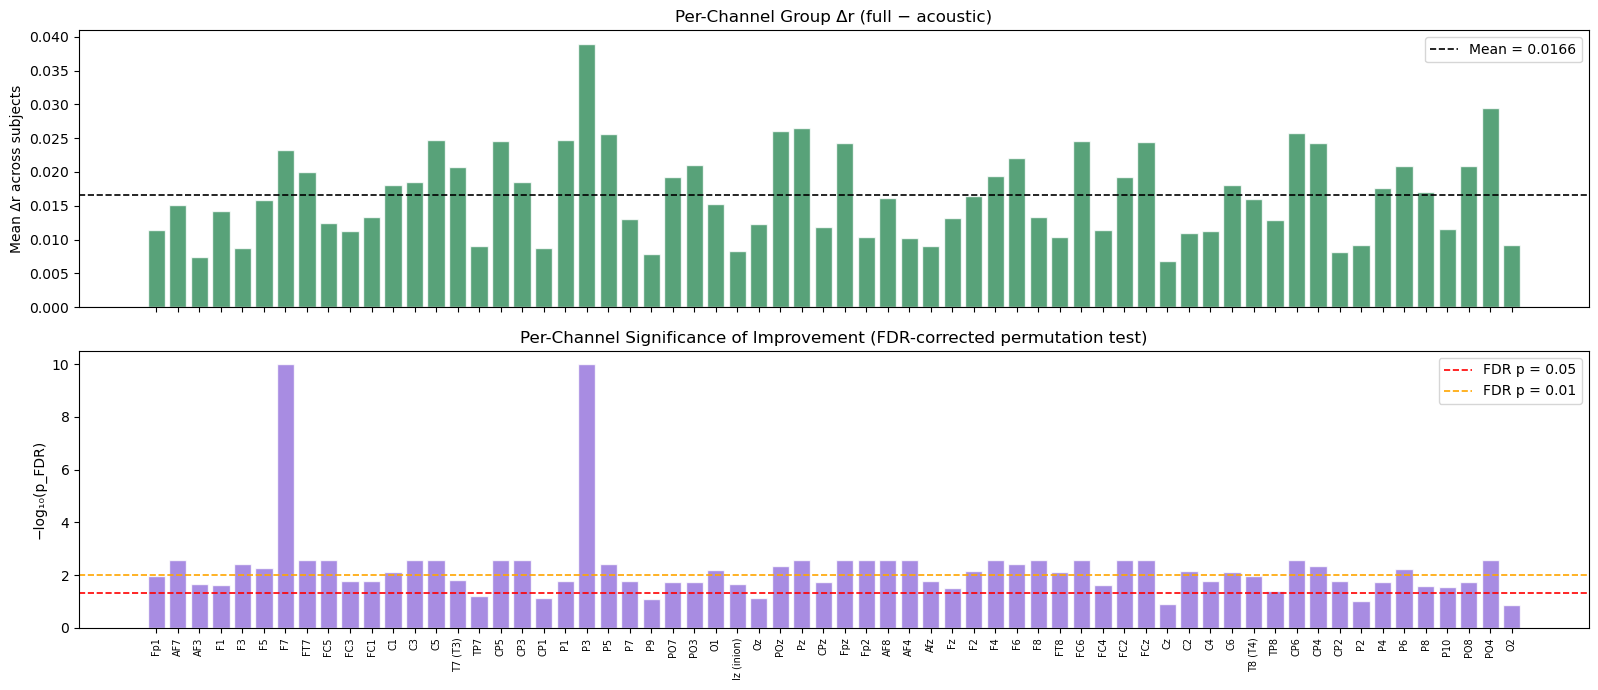

In [10]:
n_subjects = 20
pickle_folder = 'encoding_2026-04-23'
pickle_acoustic_filename = 'sklearn_ridge_acoustic_data'
pickle_surprisal_filename = 'sklearn_ridge_acoustic_and_surprisal_data'

plot(n_subjects, pickle_folder, pickle_acoustic_filename, pickle_surprisal_filename)

# After receiving the MatLab Code Improvements

  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 loaded
  Sub05 loaded
  Sub06 loaded
  Sub07 loaded
  Sub08 loaded
  Sub09 loaded
  Sub10 loaded
  Sub11 loaded
  Sub12 loaded
  Sub13 loaded
  Sub14 loaded
  Sub15 loaded
  Sub16 loaded
  Sub17 loaded
  Sub18 loaded
  Sub19 loaded
  Sub20 loaded

Loaded 20 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 0.8526  ns
  Mean Δr = -0.0003 ± 0.0011 SEM
  Channels significant after FDR (p<0.05): 1 / 64


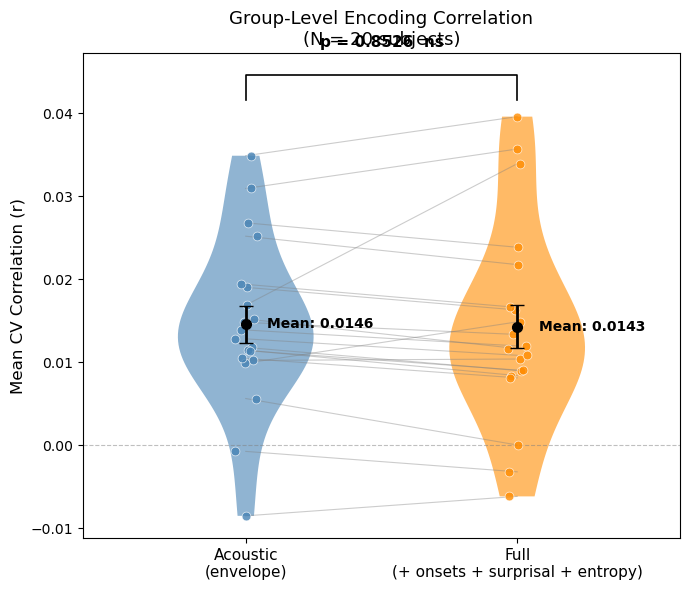

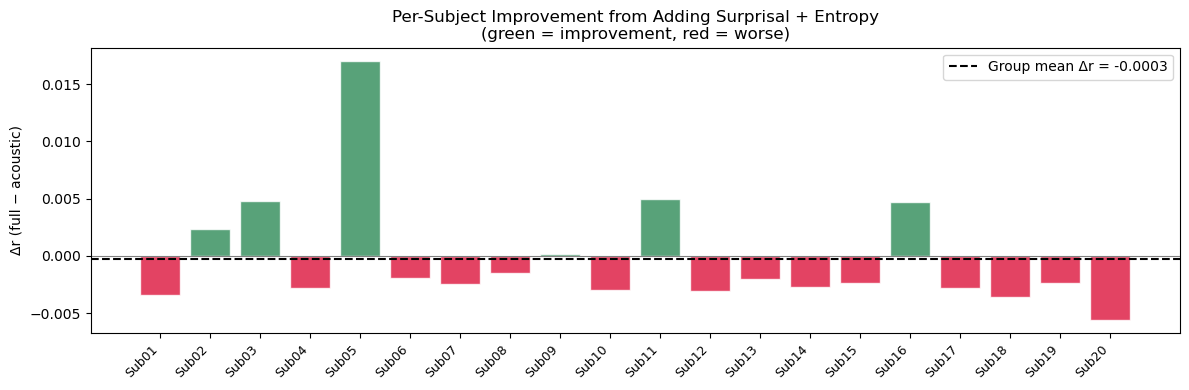

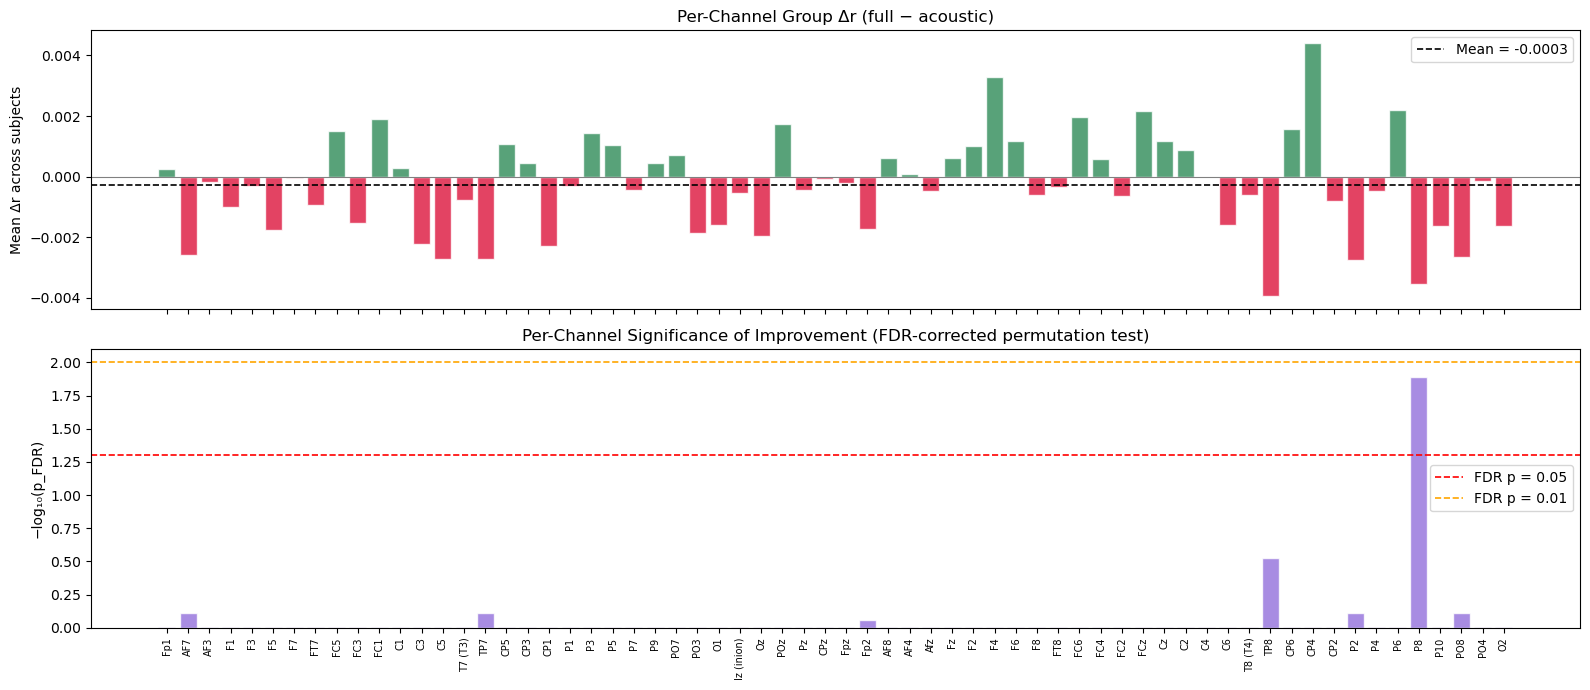

In [11]:
n_subjects = 20
pickle_folder = 'encoding_2026-05-01'
pickle_acoustic_filename = 'mne_ridge_acoustic_data'
pickle_surprisal_filename = 'mne_ridge_acoustic_and_surprisal_data'

plot(n_subjects, pickle_folder, pickle_acoustic_filename, pickle_surprisal_filename)

  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 loaded
  Sub05 loaded
  Sub06 loaded
  Sub07 loaded
  Sub08 loaded
  Sub09 loaded
  Sub10 loaded
  Sub11 loaded
  Sub12 loaded
  Sub13 loaded
  Sub14 loaded
  Sub15 loaded
  Sub16 loaded
  Sub17 loaded
  Sub18 loaded
  Sub19 loaded
  Sub20 loaded

Loaded 20 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 0.8526  ns
  Mean Δr = -0.0003 ± 0.0011 SEM
  Channels significant after FDR (p<0.05): 1 / 64


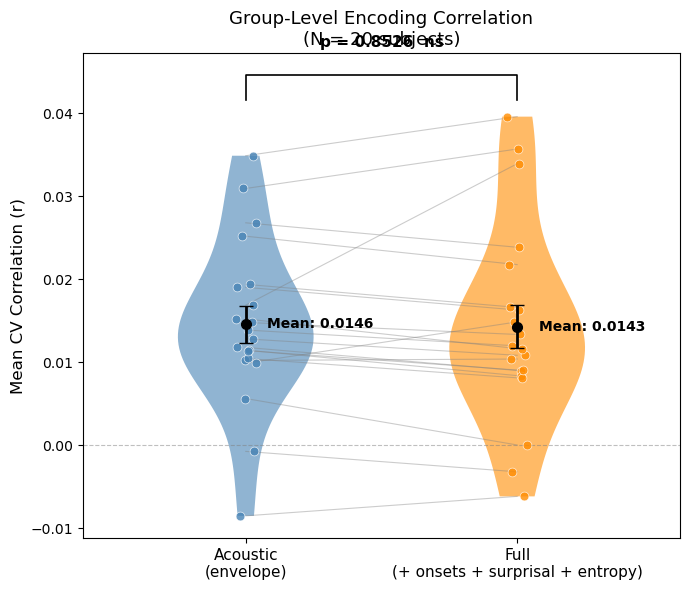

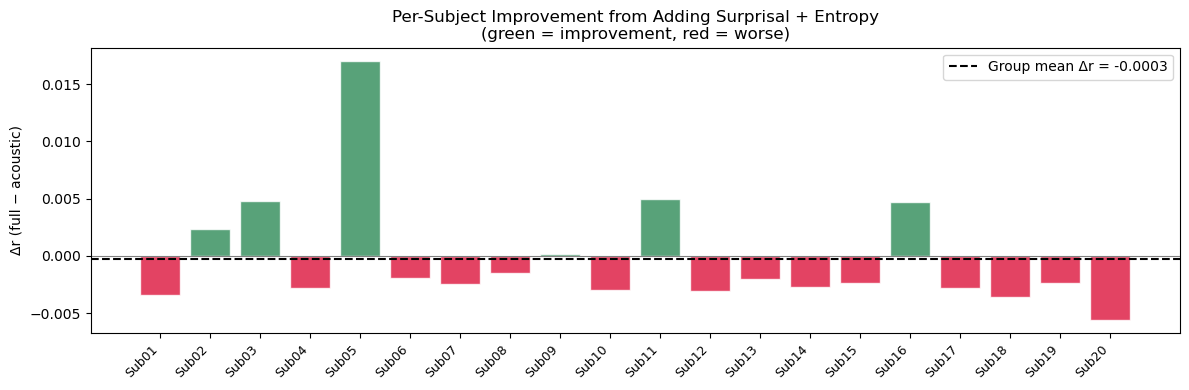

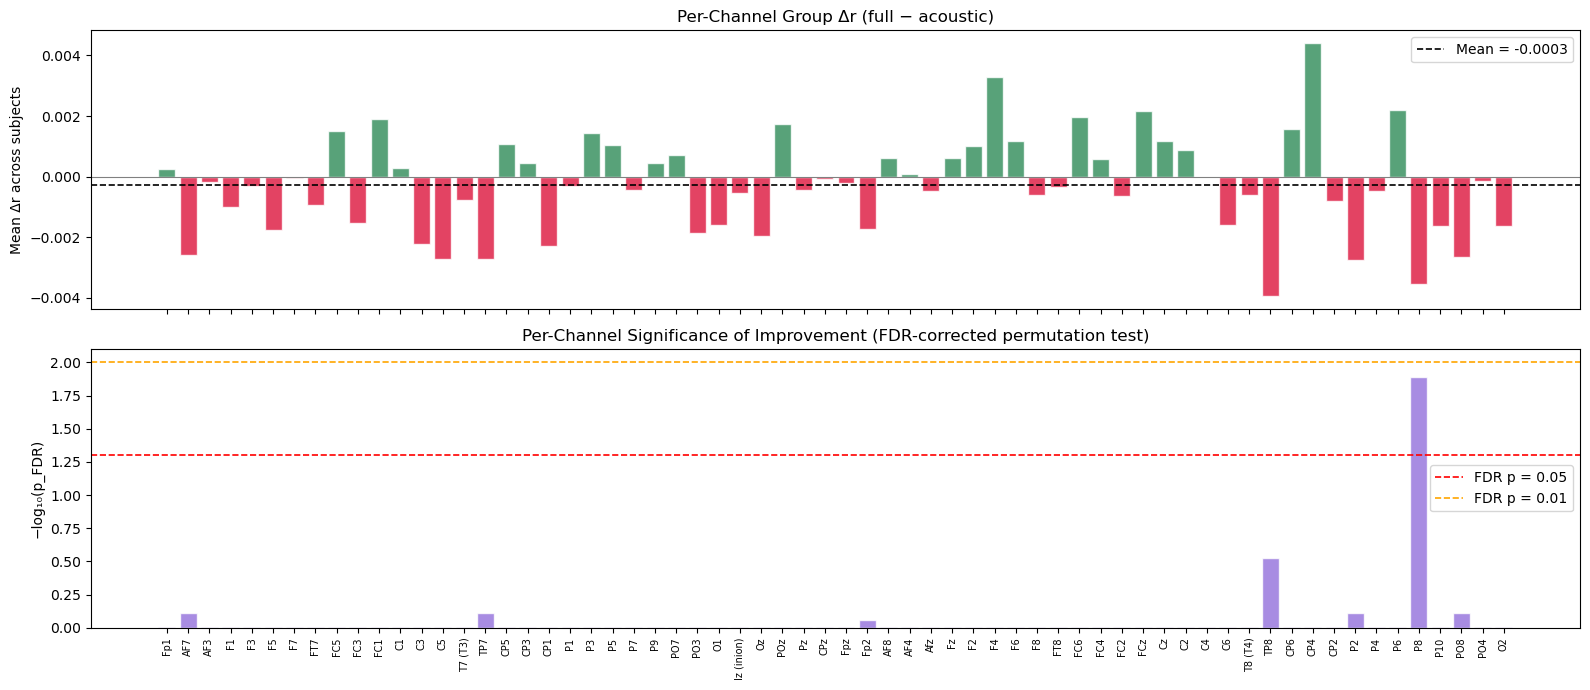

In [12]:
n_subjects = 20
pickle_folder = 'encoding_2026-05-01'
pickle_acoustic_filename = 'mne_ridge_acoustic_data'
pickle_surprisal_filename = 'mne_ridge_acoustic_and_surprisal_data'

plot(n_subjects, pickle_folder, pickle_acoustic_filename, pickle_surprisal_filename)

## After double resampling issue and alignment fixed 

  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 loaded
  Sub05 loaded
  Sub06 loaded
  Sub07 loaded
  Sub08 loaded
  Sub09 loaded
  Sub10 loaded
  Sub11 loaded
  Sub12 loaded
  Sub13 loaded
  Sub14 loaded
  Sub15 loaded
  Sub16 loaded
  Sub17 loaded
  Sub18 loaded
  Sub19 loaded
  Sub20 loaded

Loaded 20 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 0.0109  *
  Mean Δr = 0.0016 ± 0.0006 SEM
  Channels significant after FDR (p<0.05): 9 / 64


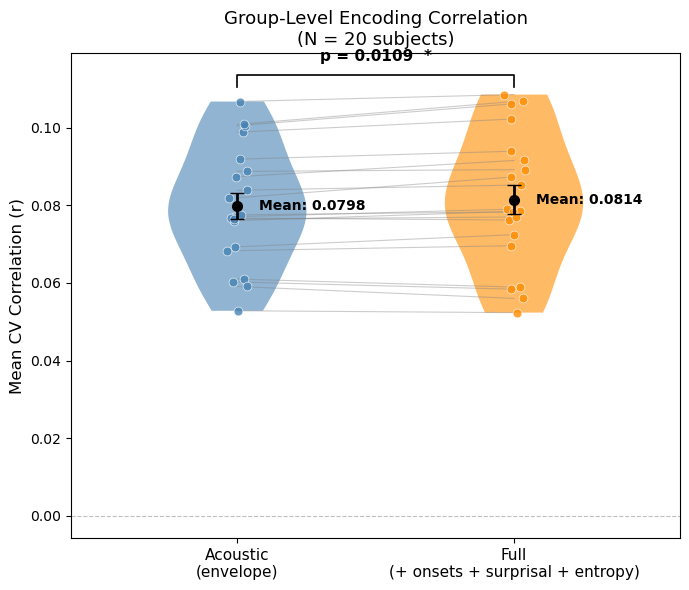

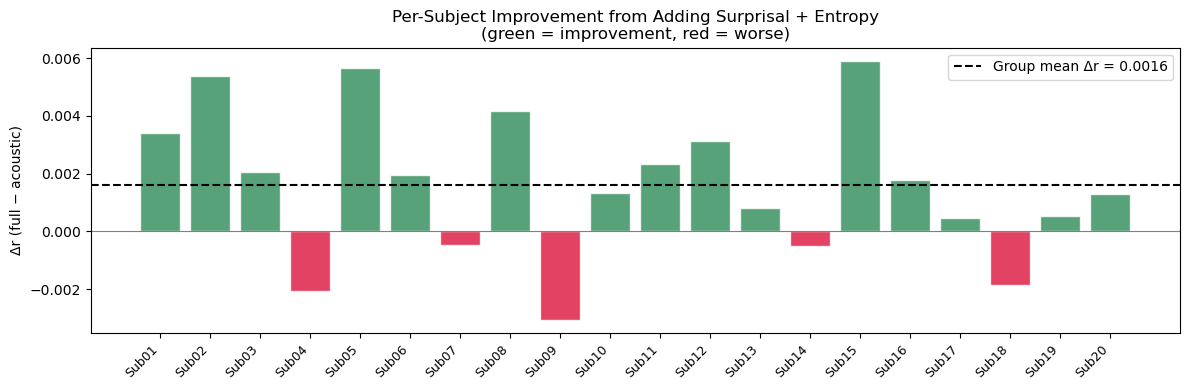

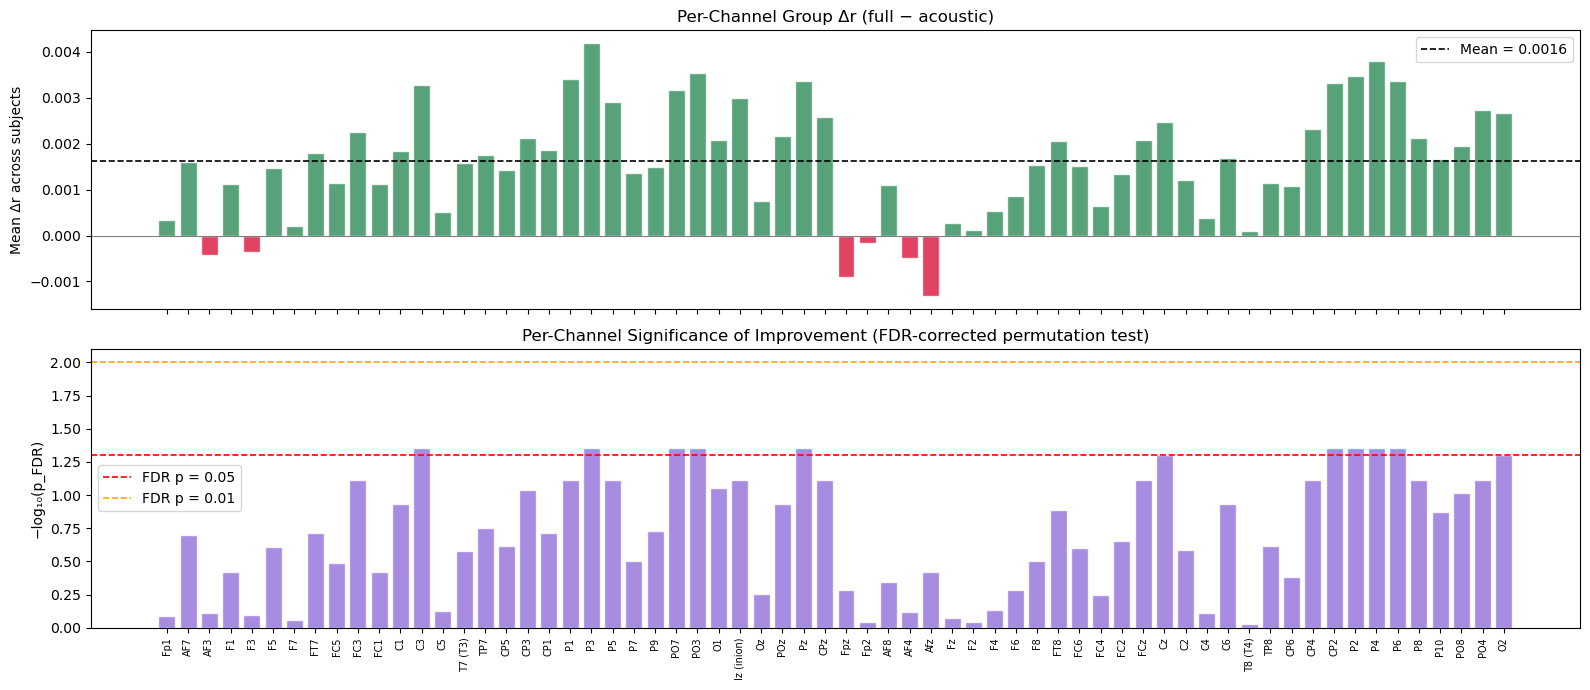

In [13]:
n_subjects = 20
pickle_folder = 'encoding_2026-05-15'
pickle_acoustic_filename = 'sklearn_ridge_acoustic_data'
pickle_surprisal_filename = 'sklearn_ridge_acoustic_and_surprisal_data'

plot(n_subjects, pickle_folder, pickle_acoustic_filename, pickle_surprisal_filename)

  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 loaded
  Sub05 loaded
  Sub06 loaded
  Sub07 loaded
  Sub08 loaded
  Sub09 loaded
  Sub10 loaded
  Sub11 loaded
  Sub12 loaded
  Sub13 loaded
  Sub14 loaded
  Sub15 loaded
  Sub16 loaded
  Sub17 loaded
  Sub18 loaded
  Sub19 loaded
  Sub20 loaded

Loaded 20 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 0.0006  ***
  Mean Δr = 0.0029 ± 0.0007 SEM
  Channels significant after FDR (p<0.05): 32 / 64


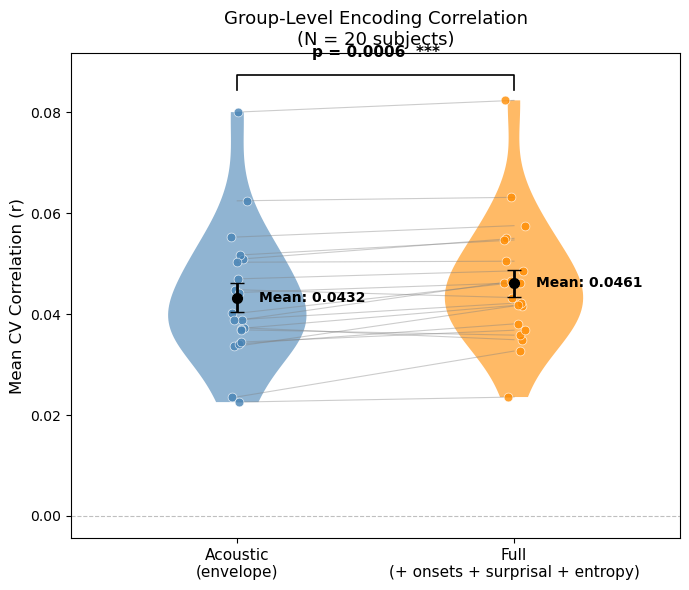

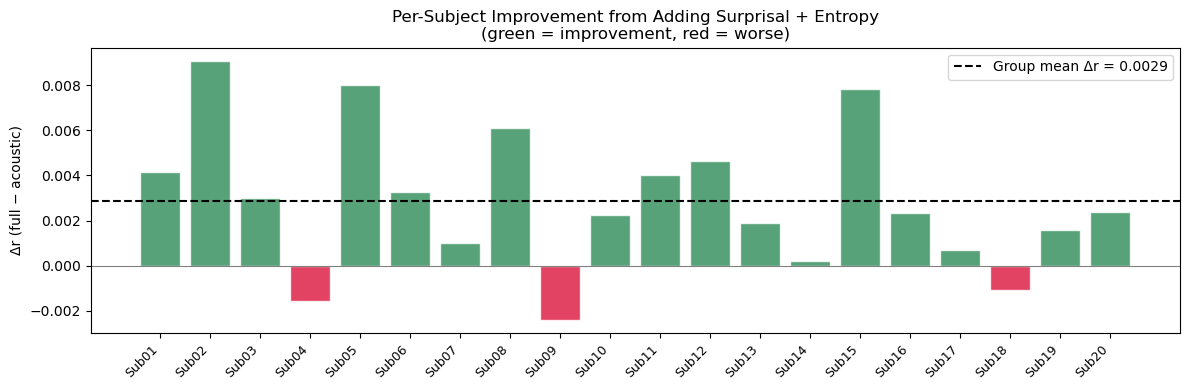

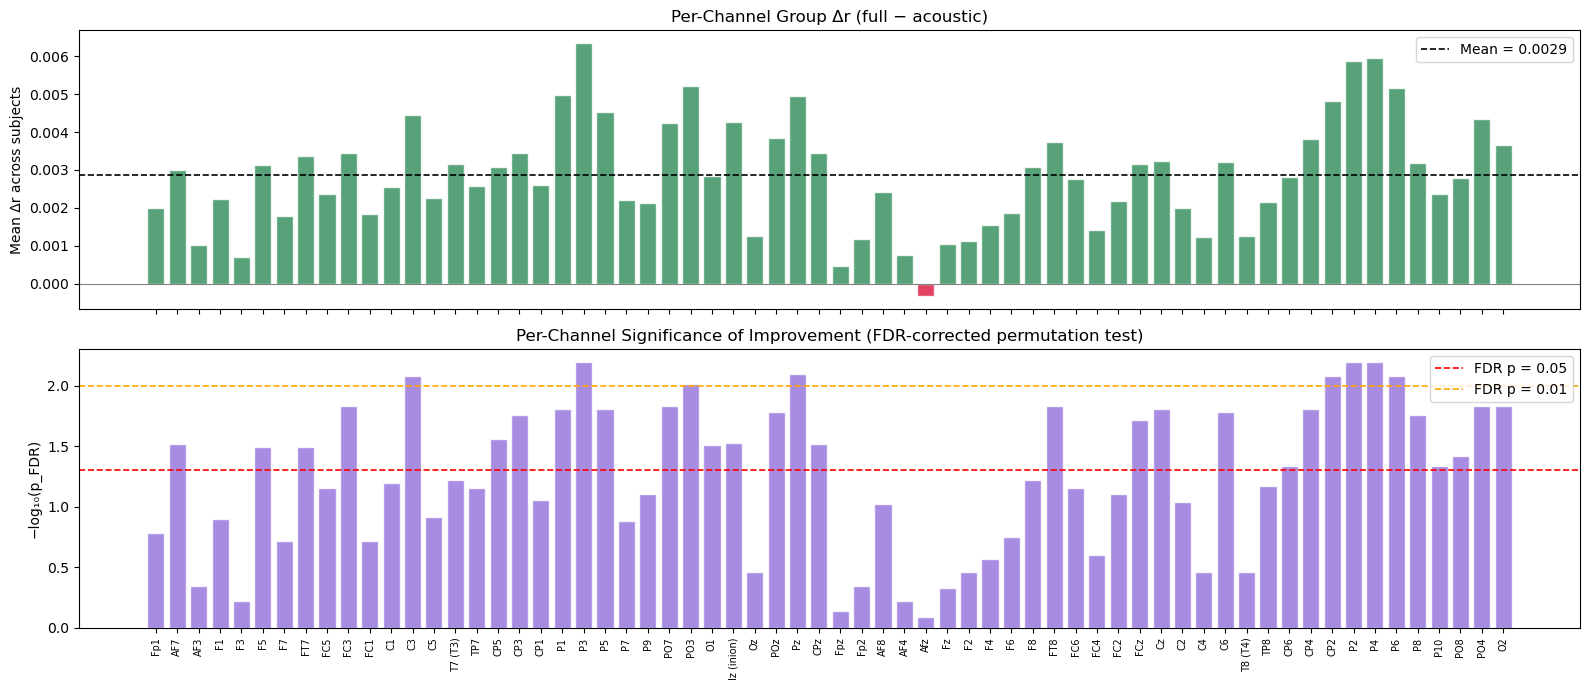

In [14]:
n_subjects = 20
pickle_folder = 'encoding_2026-05-15'
pickle_acoustic_filename = 'mne_ridge_acoustic_data'
pickle_surprisal_filename = 'mne_ridge_acoustic_and_surprisal_data'

plot(n_subjects, pickle_folder, pickle_acoustic_filename, pickle_surprisal_filename)

  Sub01 missing — skipping
  Sub02 loaded

Loaded 1 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 1.0000  ns
  Mean Δr = 0.0027 ± 0.0000 SEM
  Channels significant after FDR (p<0.05): 0 / 64


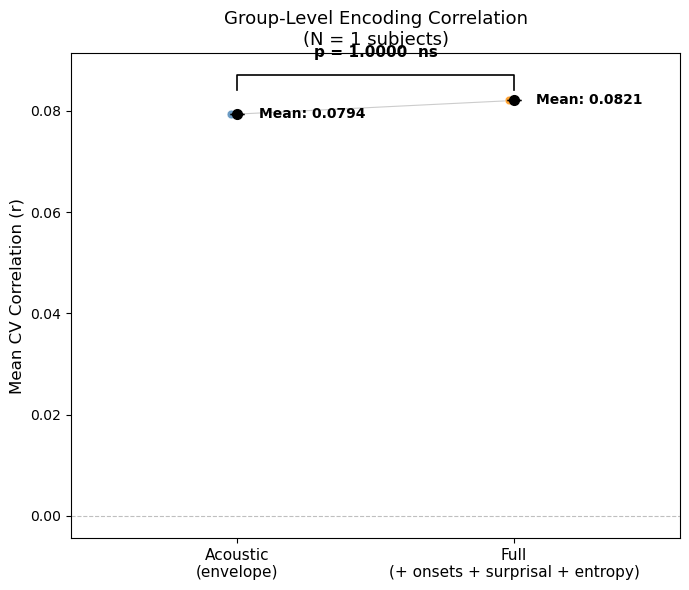

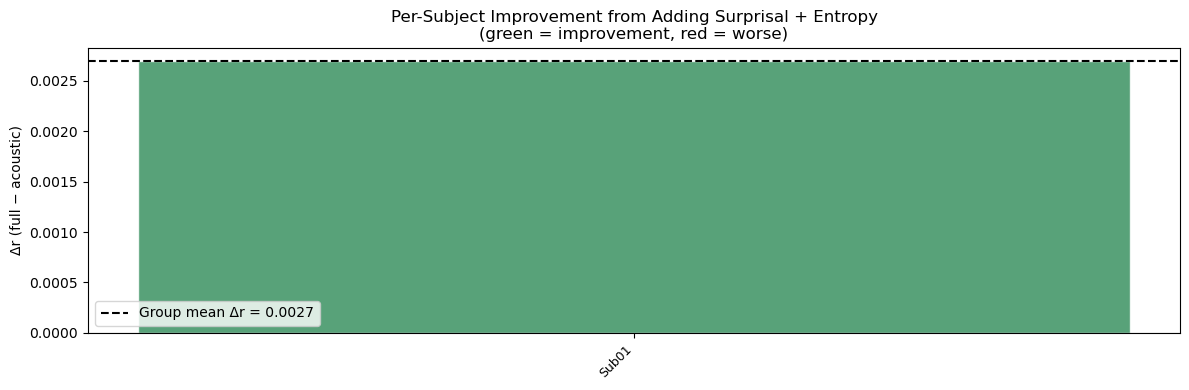

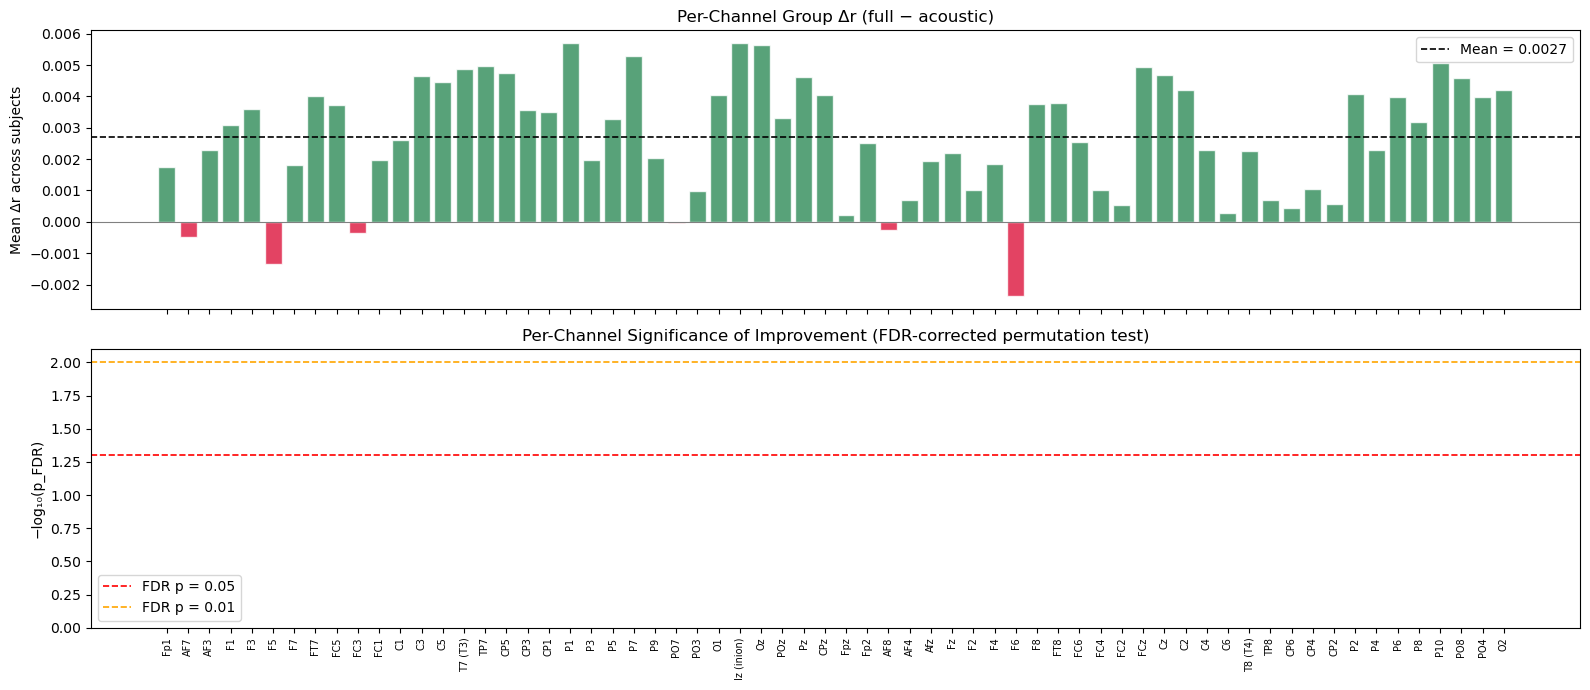

In [15]:
n_subjects = 2
pickle_folder = 'encoding_2026-05-22'
pickle_acoustic_filename = 'sklearn_ridge_acoustic_data'
pickle_surprisal_filename = 'sklearn_ridge_acoustic_and_surprisal_data'

plot(n_subjects, pickle_folder, pickle_acoustic_filename, pickle_surprisal_filename)

## Convolutional Linear Results

  Sub01 missing — skipping
  Sub02 loaded

Loaded 1 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 1.0000  ns
  Mean Δr = 0.0012 ± 0.0000 SEM
  Channels significant after FDR (p<0.05): 0 / 64


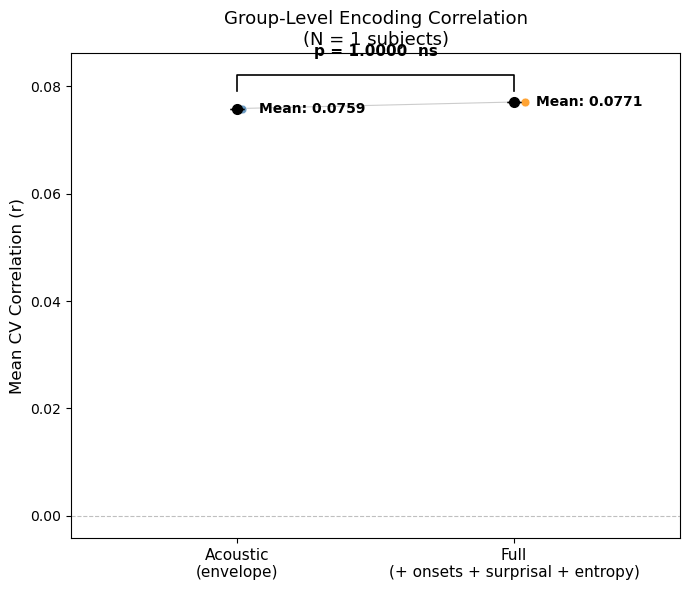

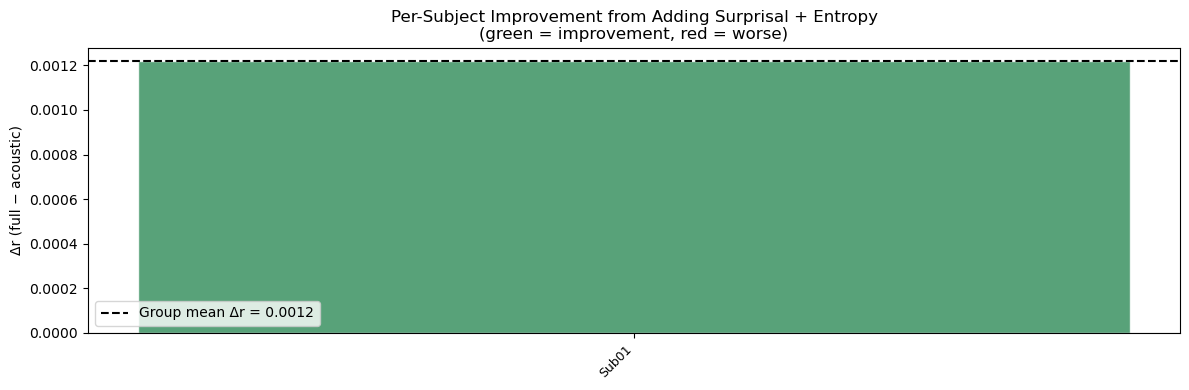

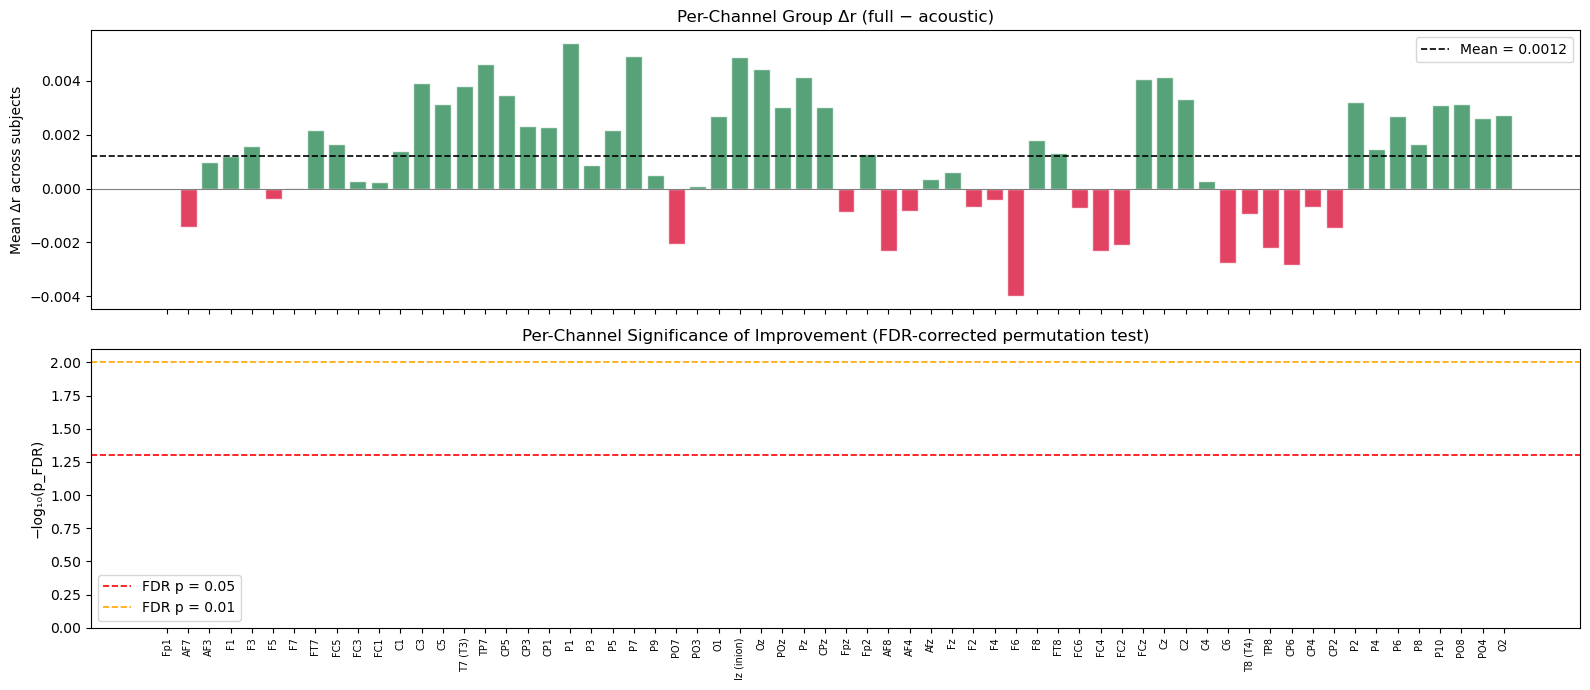

In [16]:
n_subjects = 2
pickle_folder = 'encoding_2026-05-22'
pickle_acoustic_filename = 'conv_linear_acoustic_data'
pickle_surprisal_filename = 'conv_linear_acoustic_and_surprisal_data'

plot(n_subjects, pickle_folder, pickle_acoustic_filename, pickle_surprisal_filename)

  Sub01 missing — skipping
  Sub02 loaded
  Sub03 missing — skipping
  Sub04 missing — skipping
  Sub05 missing — skipping
  Sub06 missing — skipping
  Sub07 missing — skipping
  Sub08 missing — skipping
  Sub09 missing — skipping
  Sub10 missing — skipping
  Sub11 missing — skipping
  Sub12 missing — skipping
  Sub13 missing — skipping
  Sub14 missing — skipping
  Sub15 missing — skipping
  Sub16 missing — skipping
  Sub17 missing — skipping
  Sub18 missing — skipping
  Sub19 missing — skipping
  Sub20 missing — skipping

Loaded 1 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 1.0000  ns
  Mean Δr = 0.0026 ± 0.0000 SEM
  Channels significant after FDR (p<0.05): 0 / 64


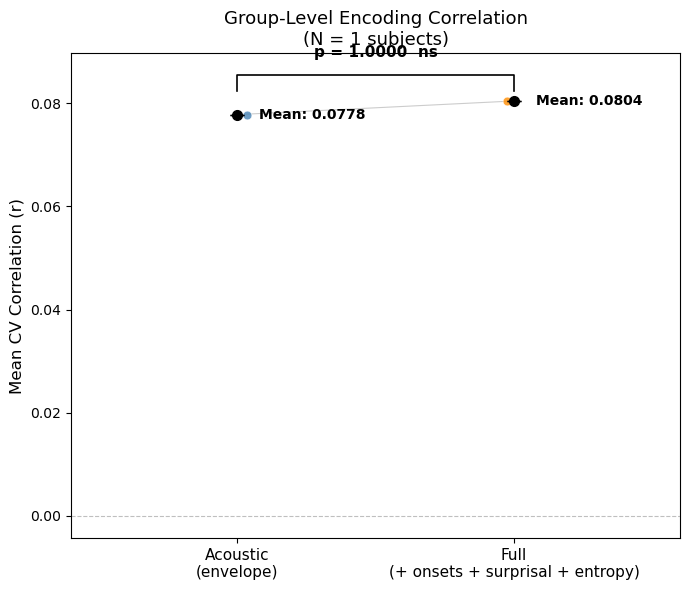

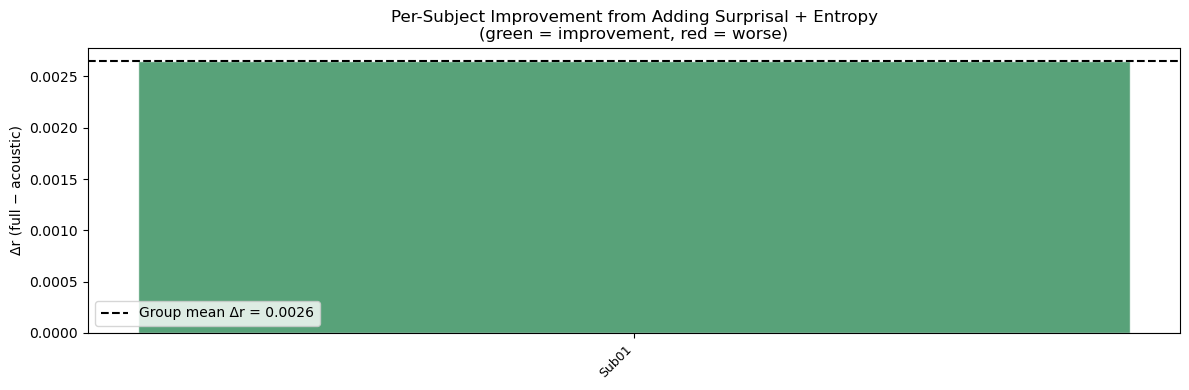

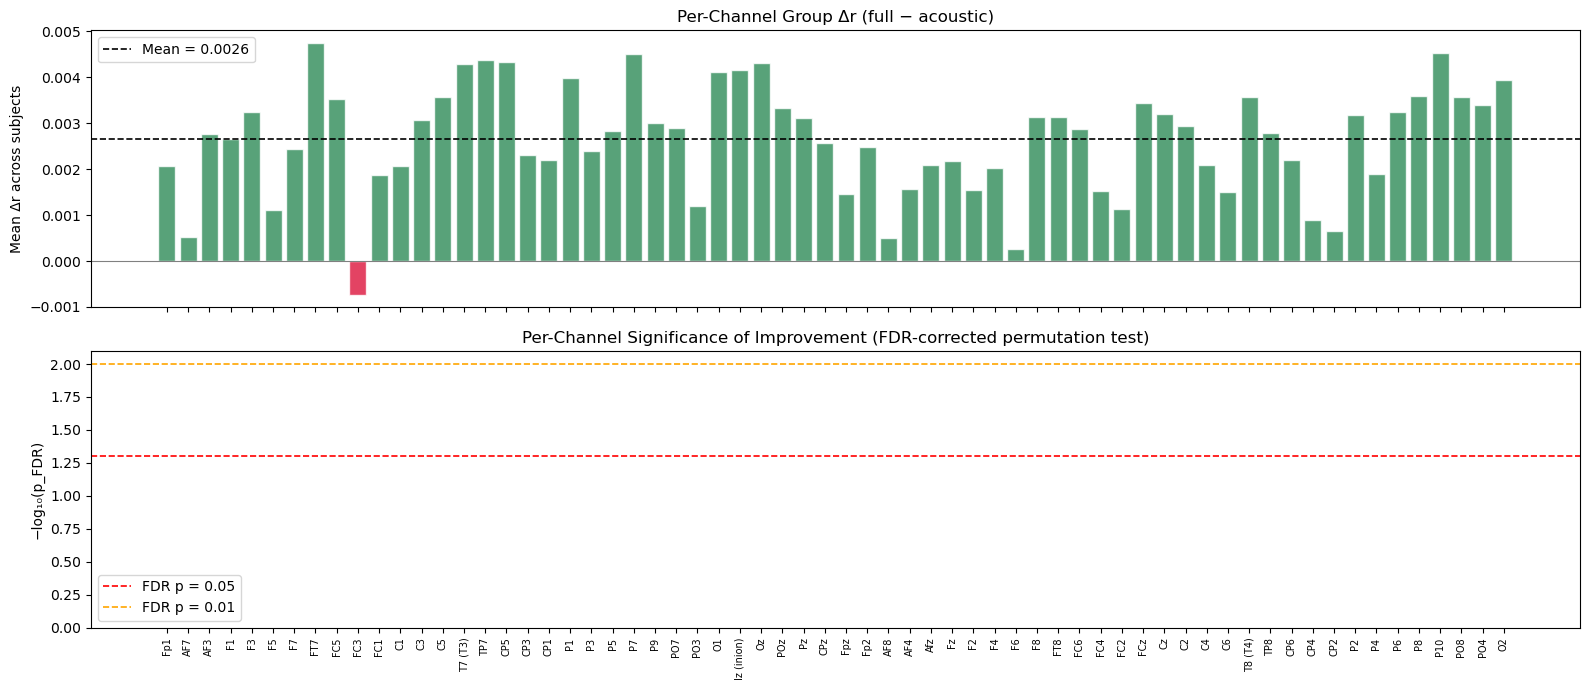

In [17]:
n_subjects = 20
pickle_folder = 'encoding_2026-05-22'
pickle_acoustic_filename = 'conv_separable_acoustic_data'
pickle_surprisal_filename = 'conv_separable_acoustic_and_surprisal_data'

plot(n_subjects, pickle_folder, pickle_acoustic_filename, pickle_surprisal_filename)

  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 loaded
  Sub05 loaded
  Sub06 loaded
  Sub07 loaded
  Sub08 loaded
  Sub09 loaded
  Sub10 loaded
  Sub11 loaded
  Sub12 loaded
  Sub13 loaded
  Sub14 loaded
  Sub15 loaded
  Sub16 loaded
  Sub17 loaded
  Sub18 loaded
  Sub19 loaded
  Sub20 loaded

Loaded 20 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 0.0000  ***
  Mean Δr = 0.0139 ± 0.0023 SEM
  Channels significant after FDR (p<0.05): 58 / 64


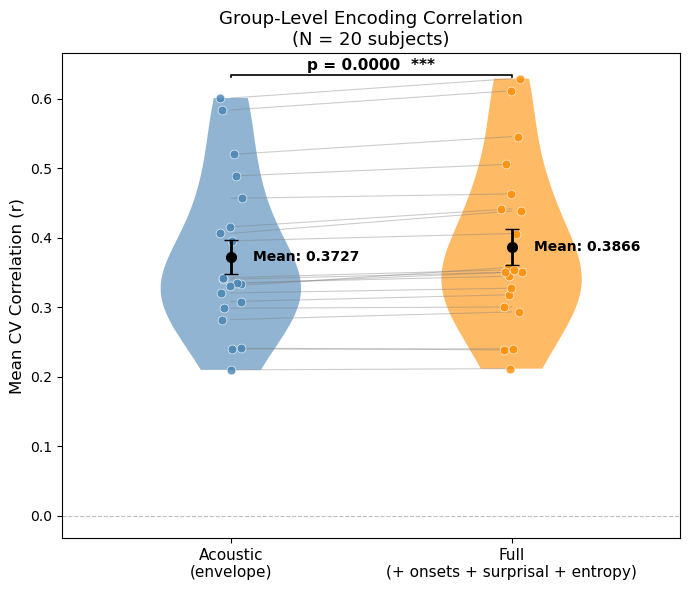

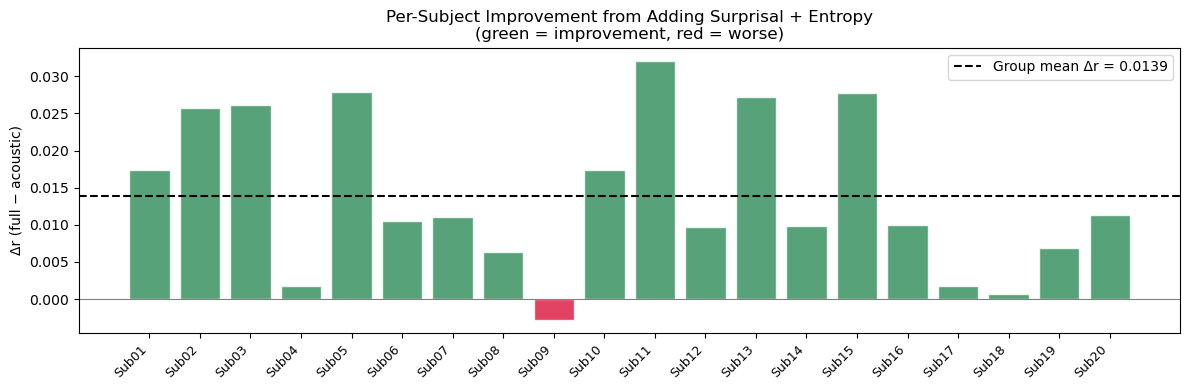

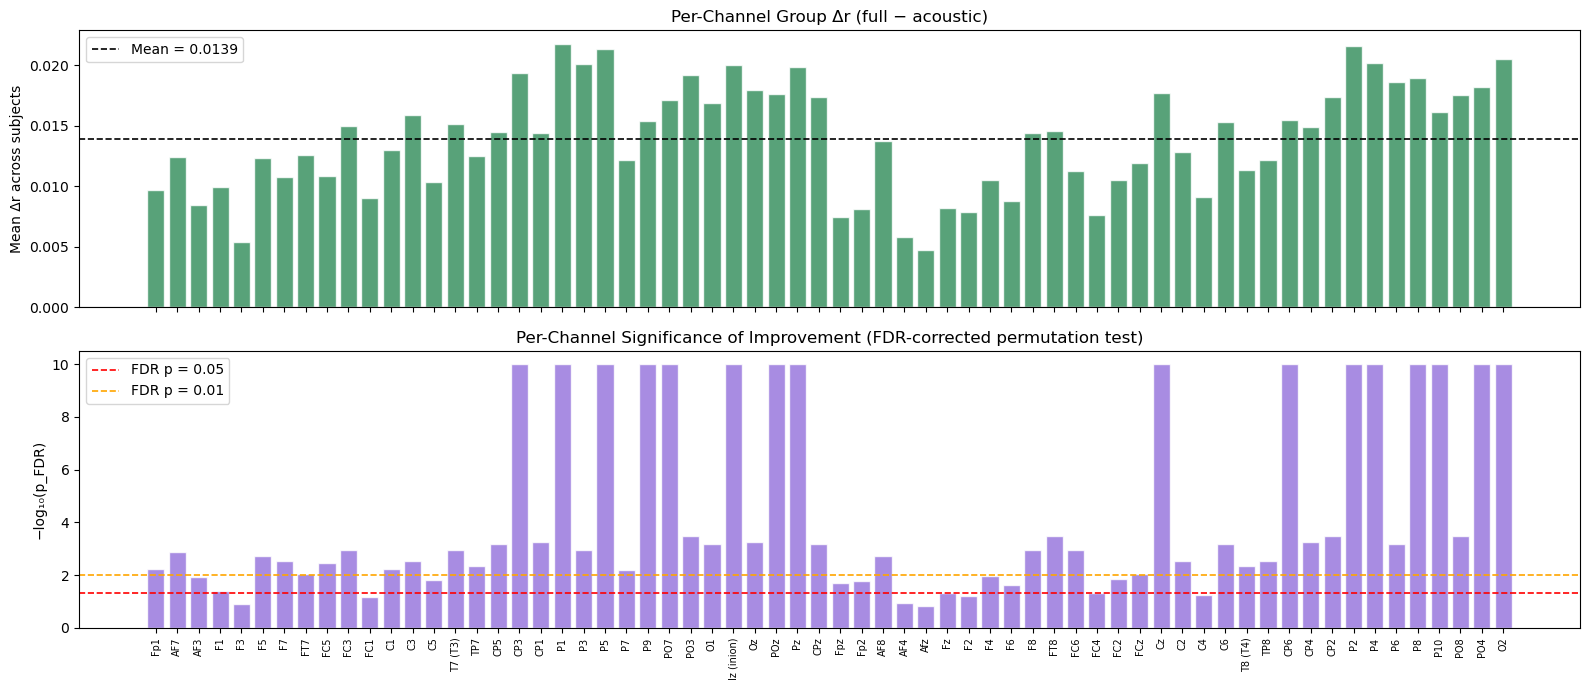

In [18]:
n_subjects = 20
pickle_folder = 'encoding_2026-05-22'
pickle_acoustic_filename = 'conv_nonlinear_acoustic_data'
pickle_surprisal_filename = 'conv_nonlinear_acoustic_and_surprisal_data'

plot(n_subjects, pickle_folder, pickle_acoustic_filename, pickle_surprisal_filename)

  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 loaded
  Sub05 loaded
  Sub06 loaded
  Sub07 loaded
  Sub08 loaded
  Sub09 loaded
  Sub10 loaded
  Sub11 loaded
  Sub12 loaded
  Sub13 loaded
  Sub14 loaded
  Sub15 loaded
  Sub16 loaded
  Sub17 loaded
  Sub18 loaded
  Sub19 loaded
  Sub20 loaded

Loaded 20 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 0.0014  **
  Mean Δr = 0.0088 ± 0.0022 SEM
  Channels significant after FDR (p<0.05): 42 / 64


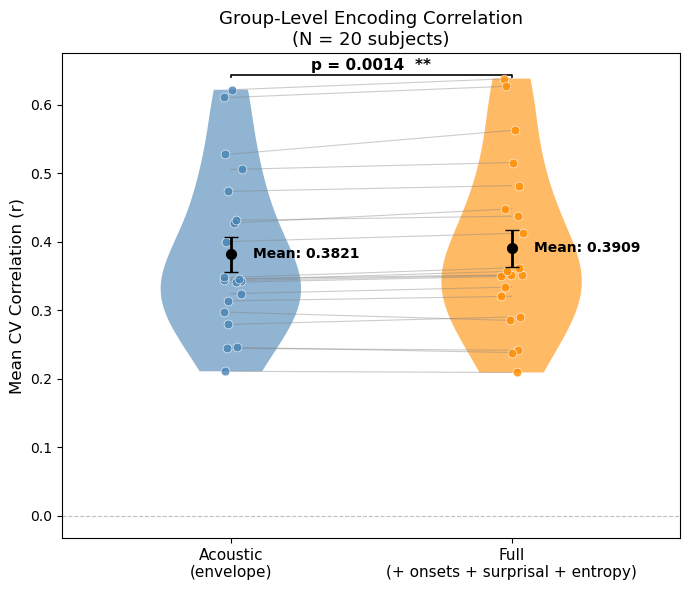

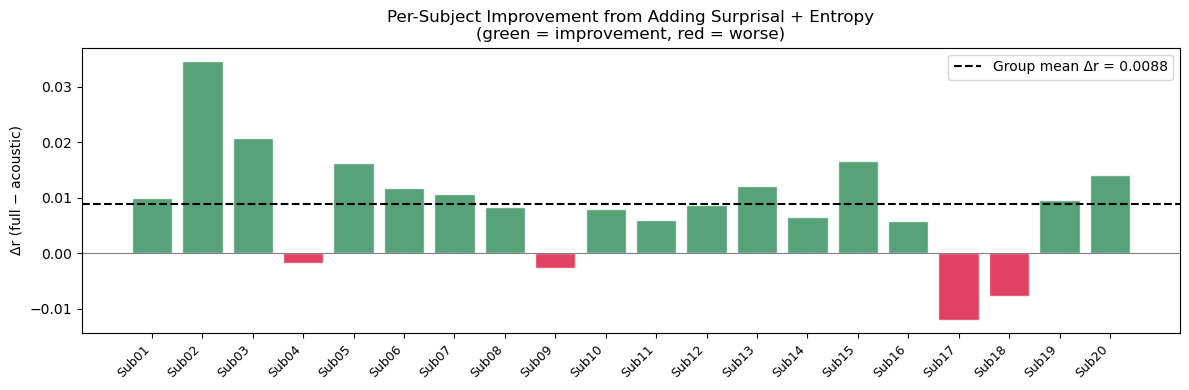

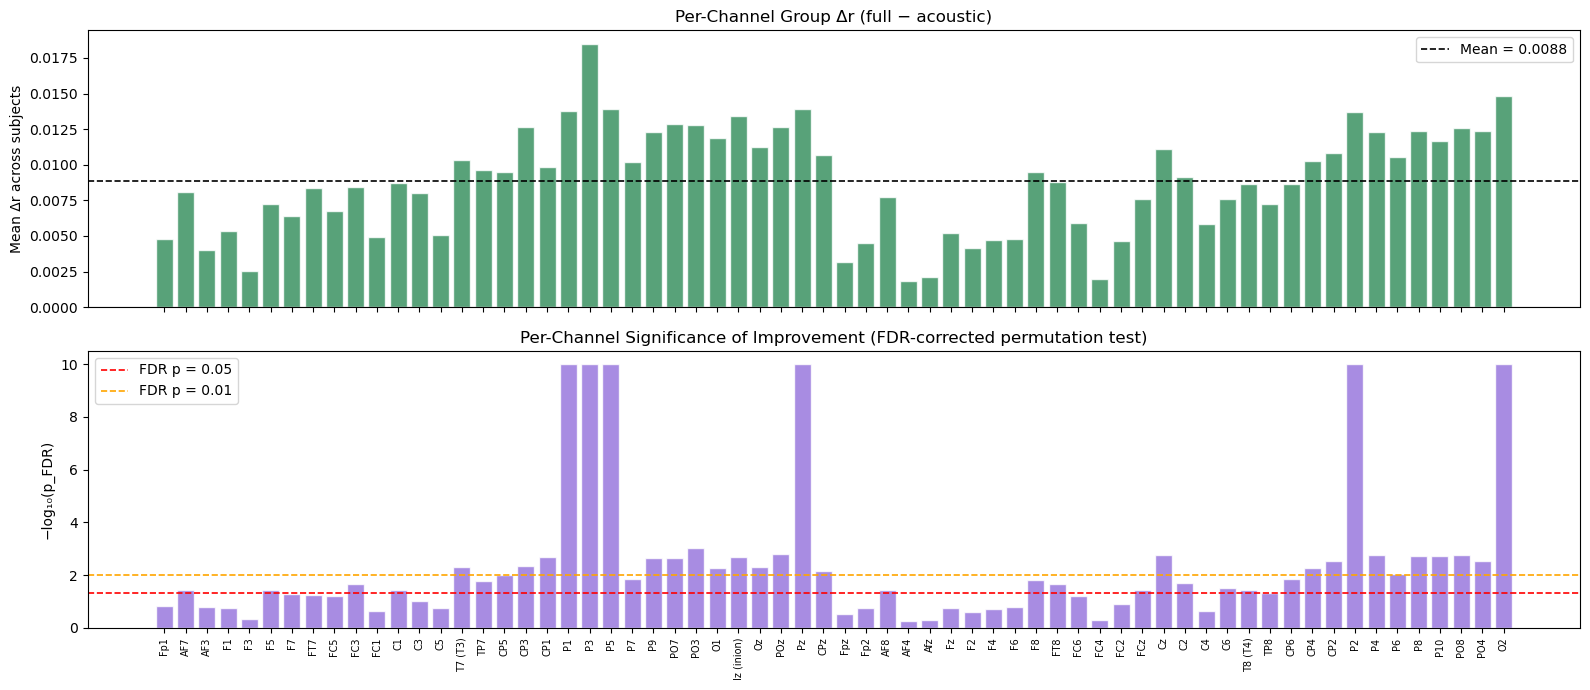

In [19]:
n_subjects = 20
pickle_folder = 'encoding_2026-05-28'
pickle_acoustic_filename = 'conv_nonlinear_acoustic_data'
pickle_surprisal_filename = 'conv_nonlinear_acoustic_and_surprisal_data'

plot(n_subjects, pickle_folder, pickle_acoustic_filename, pickle_surprisal_filename)

  Sub01 loaded

Loaded 1 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 1.0000  ns
  Mean Δr = -0.0041 ± 0.0000 SEM
  Channels significant after FDR (p<0.05): 0 / 64


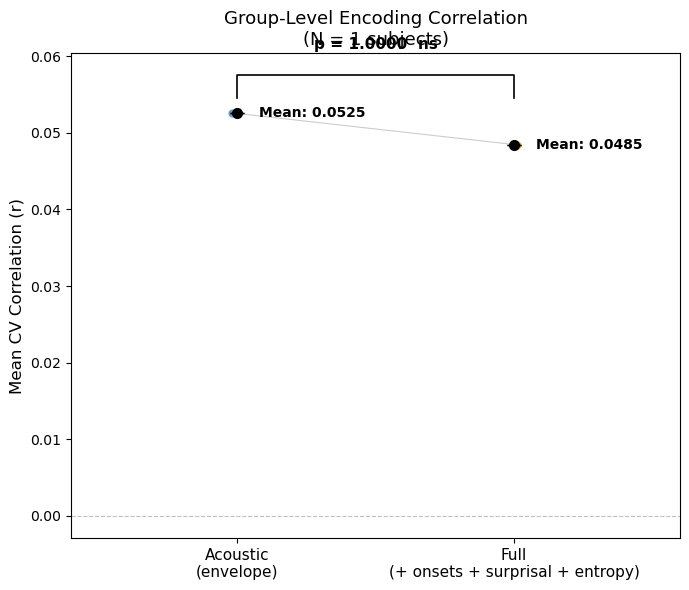

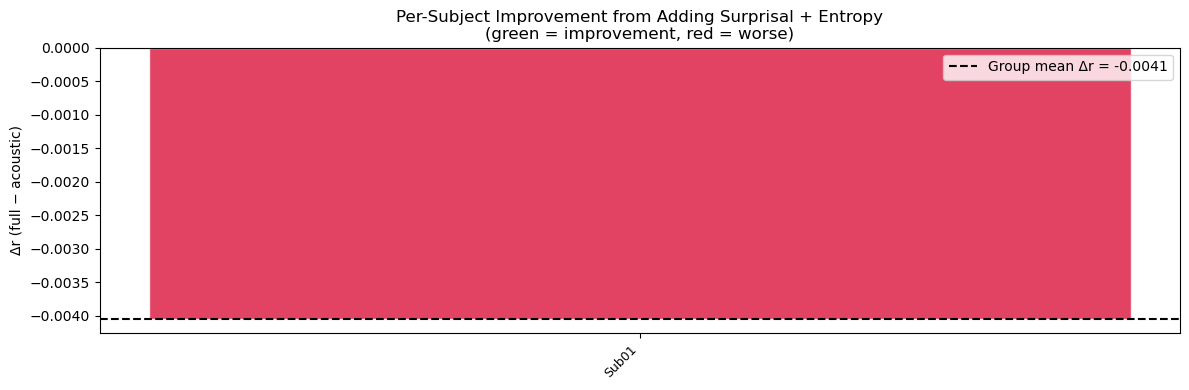

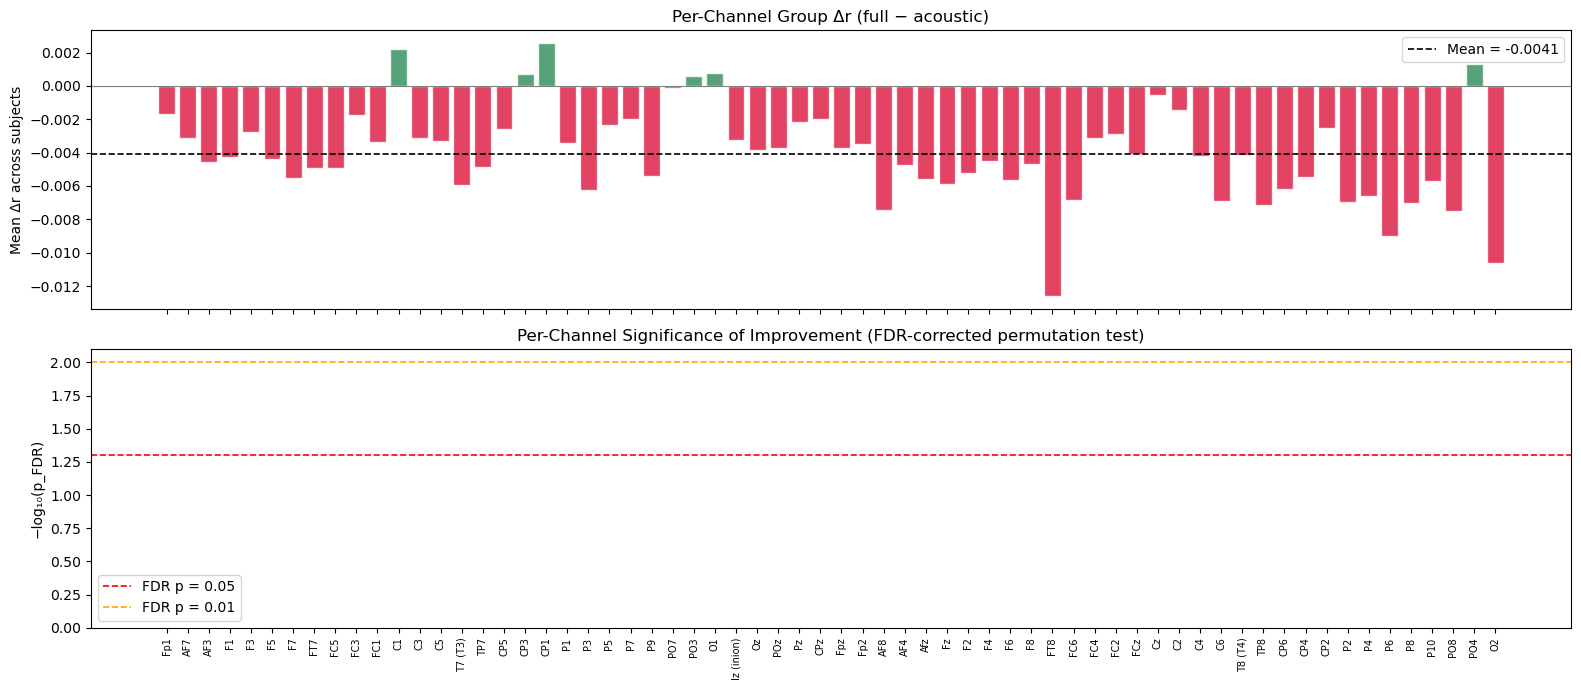

In [20]:
n_subjects = 1
pickle_folder = 'encoding_2026-06-11'
pickle_acoustic_filename = 'conv2_windowed_linear_acoustic_data'
pickle_surprisal_filename = 'conv2_windowed_linear_acoustic_and_surprisal_data'

plot(n_subjects, pickle_folder, pickle_acoustic_filename, pickle_surprisal_filename)

  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 missing — skipping

Loaded 3 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 0.7426  ns
  Mean Δr = -0.0011 ± 0.0029 SEM
  Channels significant after FDR (p<0.05): 0 / 64


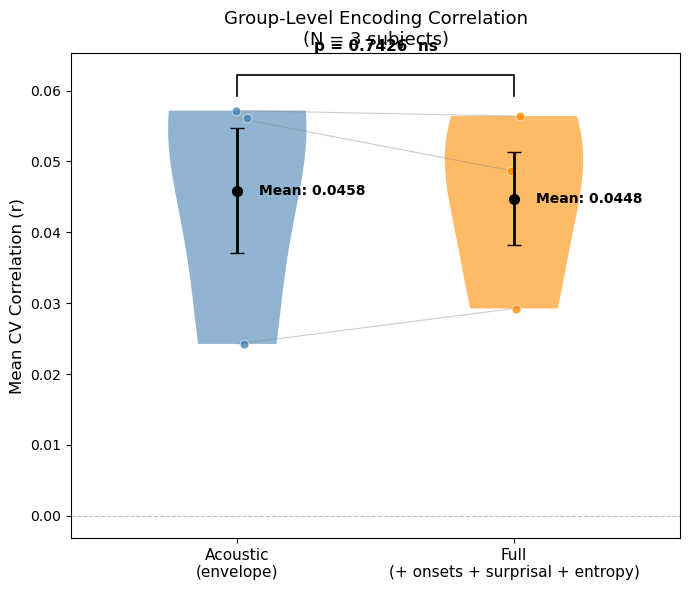

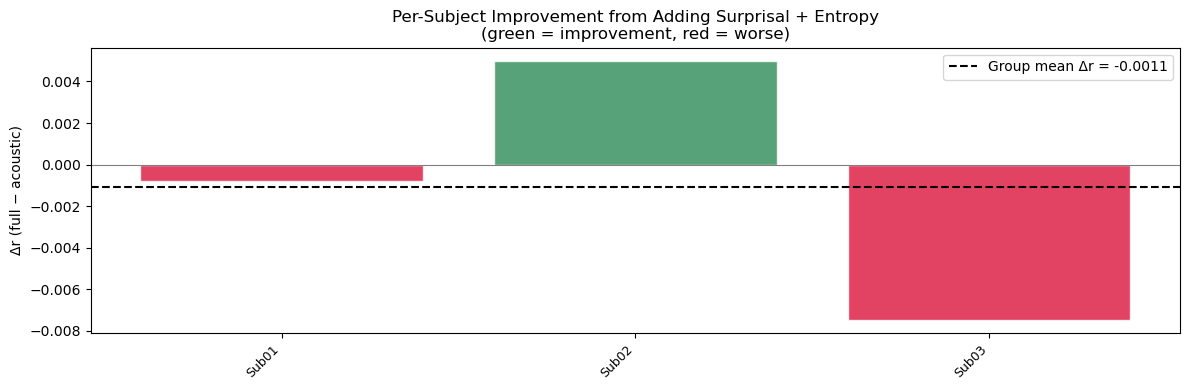

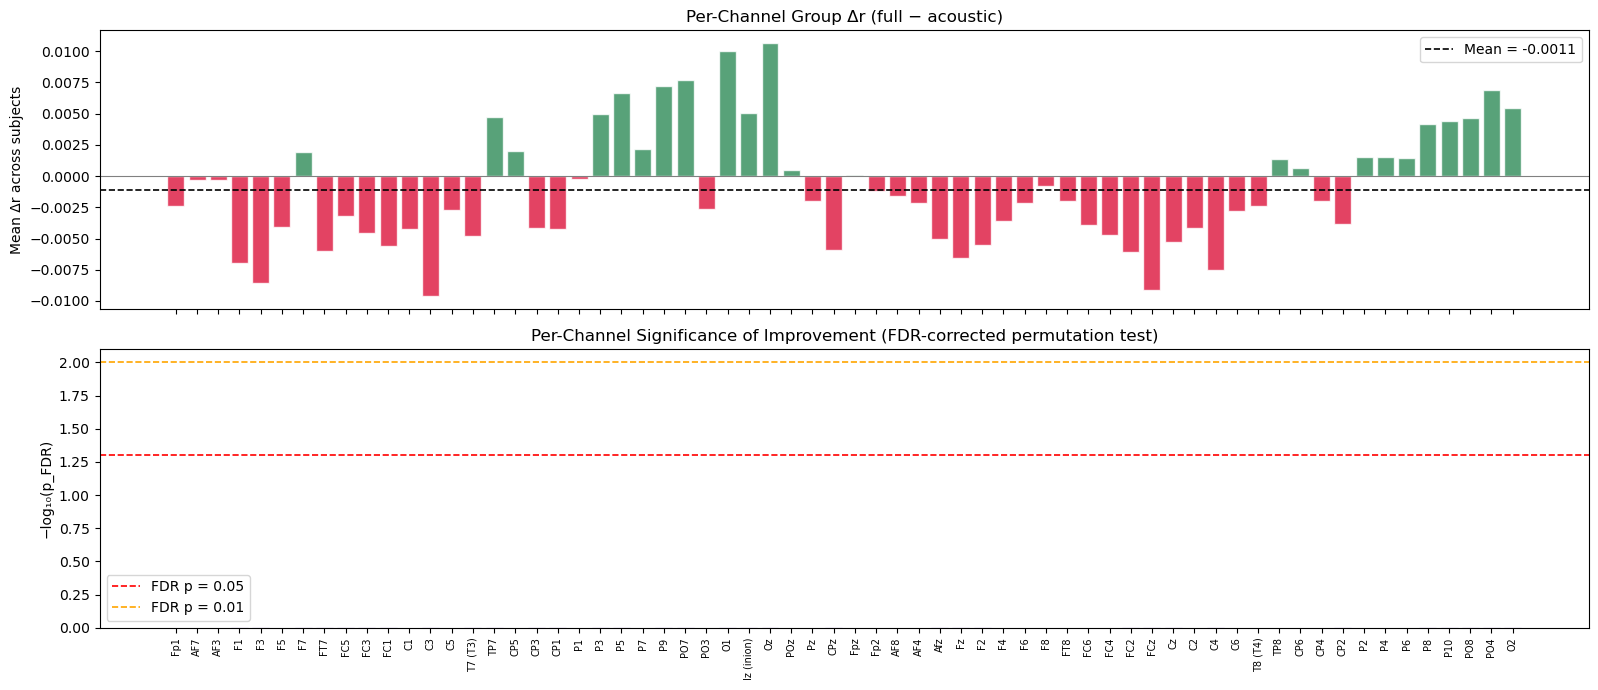

In [21]:
n_subjects = 4
pickle_folder = 'encoding_2026-06-12'
pickle_acoustic_filename = 'conv2_windowed_nonlinear_acoustic_data'
pickle_surprisal_filename = 'conv2_windowed_nonlinear_acoustic_and_surprisal_data'

plot(n_subjects, pickle_folder, pickle_acoustic_filename, pickle_surprisal_filename)